In [ ]:
from google.colab import auth
auth.authenticate_user()
from google.cloud import bigquery
client = bigquery.Client(project = "data-analytics-mate")

# E-commerce Sales Analytics

## Business goal

**EN:**  
Analyze sales performance across geography, traffic channels, devices, and user segments to identify key revenue drivers, monetization gaps, and statistically significant patterns in user behavior.

**UA:**  
Проаналізувати продажі за географією, каналами трафіку, девайсами та сегментами користувачів, щоб виявити ключові драйвери доходу, зони слабкої монетизації та статистично значущі патерни поведінки.



## Data source and extraction

**EN:**  
Data was extracted from Google BigQuery using SQL.  
The dataset is built at the **session–product level**.

Since a separate order identifier is not available, each unique session with **positive revenue** is treated as a completed order.

**UA:**  
Дані були отримані з Google BigQuery за допомогою SQL.  
Датасет має зерно **session–product**.

Оскільки окремого ідентифікатора замовлення немає, кожна унікальна сесія з **позитивним доходом** вважається замовленням.



In [ ]:
base_dataset_sql = """
WITH base_dataset AS (
  SELECT
    s.date,
    s.ga_session_id,

    -- geo & device
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,

    -- normalized traffic source
    CASE
      WHEN sp.medium = 'organic' THEN 'Organic Search'
      WHEN sp.medium = 'cpc' THEN 'Paid Search'
      WHEN sp.medium = 'referral' THEN 'Referral'
      WHEN sp.medium = '(none)' AND sp.name = '(direct)' THEN 'Direct'
      WHEN sp.medium = '<Other>' THEN 'Other'
      WHEN sp.medium = '(data deleted)' THEN 'Data Removed'
      ELSE 'Unknown'
    END AS traffic_source,

    -- raw channel
    sp.channel,

    -- user info (nullable)
    acc.account_id AS registered_user_id,
    a.is_verified,
    a.is_unsubscribed,

    -- product & revenue
    p.category,
    p.name AS product_name,
    p.price,
    p.short_description

  FROM `DA.session` s
  LEFT JOIN `DA.order` o
    ON s.ga_session_id = o.ga_session_id
  LEFT JOIN `DA.product` p
    ON o.item_id = p.item_id
  LEFT JOIN `DA.session_params` sp
    ON s.ga_session_id = sp.ga_session_id
  LEFT JOIN `DA.account_session` acc
    ON s.ga_session_id = acc.ga_session_id
  LEFT JOIN `DA.account` a
    ON acc.account_id = a.id
)

-- ===============================
-- 2. FILTERED DATA
-- ===============================


  SELECT *
  FROM base_dataset
  WHERE price IS NOT NULL
    AND price > 0
"""


**EN:**  
The original `channel` field was retained for comparison purposes.  
A separate normalized `traffic_source` field was created using business rules to ensure consistent attribution.

**UA:**  
Оригінальний стовпчик `channel` збережено для порівняння.  
Окреме нормалізоване поле `traffic_source` створено на основі бізнес-логіки для коректної атрибуції.
  


In [ ]:
df_raw = client.query(base_dataset_sql).to_dataframe()
df_raw.head() # Виведення датафрейму/Dataframe output

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,registered_user_id,is_verified,is_unsubscribed,category,product_name,price,short_description
0,2020-11-01,6260592731,Americas,United States,mobile,Chrome,Pixel 3,Web,None,Organic Search,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-02,9287517789,Asia,India,mobile,Chrome,Pixel 3,Web,None,Direct,Direct,<NA>,<NA>,<NA>,Chairs,NORDVIKEN / HENRIKSDAL,2675.0,"Table and 4 chairs, 152/223x95 cm"
2,2020-11-02,8202854533,Americas,United States,mobile,Chrome,Pixel 3,Web,en-us,Organic Search,Organic Search,<NA>,<NA>,<NA>,Sofas & armchairs,LIDHULT,5810.0,"Corner sofa, 5-seat"
3,2020-11-02,2401617513,Americas,United States,mobile,Chrome,Pixel 4 XL,Android,None,Referral,Paid Search,<NA>,<NA>,<NA>,Nursery furniture,SMÅGÖRA,95.0,"Shelf unit, 29x88 cm"
4,2020-11-03,6315247329,Americas,United States,mobile,Chrome,Pixel 4 XL,Web,en-us,Organic Search,Organic Search,<NA>,<NA>,<NA>,Beds,HEMNES,995.0,"Bed frame, 90x200 cm"


**EN:**  
The preview below was used to validate schema consistency, key dimensions, and revenue availability.

**UA:**  
Попередній перегляд використано для перевірки структури даних, ключових вимірів та наявності доходу.


In [ ]:
# Clean dataset used for all downstream analysis
# Очищений датасет для подальшого аналізу
df = df_raw[
    (df_raw["traffic_source"] != "Data Removed") &
    (df_raw["price"] > 0)
].copy()


**EN:**  
Records labeled as "Data Removed" represent incomplete or invalid attribution and were excluded from the analysis.  
Only sessions with positive revenue were used for sales-related metrics.

**UA:**  
Записи з міткою "Data Removed" є технічними артефактами та були виключені з аналізу.  
Для розрахунку продажів використовувались лише сесії з позитивним доходом.


In [ ]:
# Основні бібліотеки для аналізу / Basic libraries for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset overview
This section provides a high-level understanding of the dataset structure and data quality.


In [ ]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                33538 non-null  dbdate 
 1   ga_session_id       33538 non-null  Int64  
 2   continent           33538 non-null  object 
 3   country             33538 non-null  object 
 4   device              33538 non-null  object 
 5   browser             33538 non-null  object 
 6   mobile_model_name   33538 non-null  object 
 7   operating_system    33538 non-null  object 
 8   language            22531 non-null  object 
 9   traffic_source      33538 non-null  object 
 10  channel             33538 non-null  object 
 11  registered_user_id  2781 non-null   Int64  
 12  is_verified         2781 non-null   Int64  
 13  is_unsubscribed     2781 non-null   Int64  
 14  category            33538 non-null  object 
 15  product_name        33538 non-null  object 
 16  pric

 Feature engineering

In [ ]:
df['date'] = pd.to_datetime(df['date'])

The date column was converted to `datetime` format, and the month was extracted to facilitate further time-based analysis and aggregation.


- 33,538 records
- 18 columns (categorical, numeric, datetime)
- Time range: Nov 2020 – Jan 2021
- No duplicate sessions detected

EN:
Product name normalization was unnecessary because analysis is performed at the category level, and product names are not used as analytical keys.

UA:
Нормалізація назв продуктів була зайвою, оскільки аналіз проводиться на рівні категорій, а назви продуктів не використовуються як ключові змінні.


##Search for outliers

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "column": col,
        "outliers_count": outliers_count,
        "outliers_share": outliers_count / len(df)
    })

outliers_df = (
    pd.DataFrame(outlier_summary)
    .sort_values("outliers_share", ascending=False)
)

outliers_df


,column,outliers_count,outliers_share
4,price,2631,0.083681
3,is_unsubscribed,421,0.013390
0,ga_session_id,0,0.000000
2,is_verified,0,0.000000
1,registered_user_id,0,0.000000


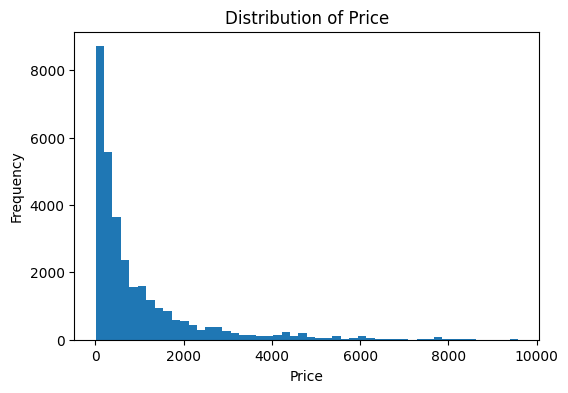

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Price")
plt.show()

EN:
Price outliers were identified but retained, as they likely represent legitimate high-value purchases rather than data errors.

UA:
Аномальні значення цін були виявлені, але збережені, оскільки вони, ймовірно, відповідають реальним покупкам з високою вартістю, а не помилкам у даних.

#Metrics

## Business Questions



1.   In which countries or continents are there many orders but low revenue?


2.  Which categories generate most of the revenue, and are there categories with high demand but low monetization?


1.   Which channels generate revenue, and which drive traffic with low business value?
2.   Does email subscription impact actual sales, and is email marketing a worthwhile investment?




1.   During which periods does the business experience revenue decline, and when should marketing efforts be intensified or strategy adjusted?
2.    How is revenue distributed across device types, and does AOV differ between them?


## Sales performance by Geography

**Question:**  
EN:
In which countries or continents are there many orders but low revenue?


In [ ]:
continent_perf = (
    df
    .groupby('continent', dropna=False)
    .agg(
        orders=('ga_session_id', 'nunique'),
        total_revenue=('price', 'sum')
    )
)

continent_perf['aov'] = (
    continent_perf['total_revenue'] / continent_perf['orders']
)

continent_perf = continent_perf.sort_values('orders', ascending=False)

continent_perf


,orders,total_revenue,aov
continent,,,
Americas,17361,16498661.2,950.328967
Asia,7445,7089791.6,952.288999
Europe,5912,5612851.7,949.399814
Oceania,337,342193.2,1015.410089
Africa,319,318634.0,998.852665
(not set),67,67678.4,1010.125373


In [ ]:
orders_median = continent_perf['orders'].median()
global_aov = df["price"].sum() / df["ga_session_id"].nunique()

low_value_continents = continent_perf[
    (continent_perf['orders'] > orders_median) &
    (continent_perf['aov'] < global_aov)
]

low_value_continents


,orders,total_revenue,aov
continent,,,
Americas,17361,16498661.2,950.328967
Europe,5912,5612851.7,949.399814


EN:
Continents were evaluated against the global average order value to identify under-monetized high-volume regions.

UA:
Континенти оцінювались відносно глобального середнього чеку для виявлення регіонів із високим обсягом замовлень, але слабкою монетизацією.

In [ ]:
country_perf = (
    df
    .groupby('country', dropna=False)
    .agg(
        orders=('ga_session_id', 'nunique'),
        total_revenue=('price', 'sum')
    )
)

country_perf['aov'] = (
    country_perf['total_revenue'] / country_perf['orders']
)

country_perf = country_perf.sort_values('orders', ascending=False)

country_perf.head(10)


,orders,total_revenue,aov
country,,,
United States,13736,13005638.8,946.828684
India,2846,2615976.5,919.176564
Canada,2413,2302885.2,954.366017
United Kingdom,977,890656.4,911.623746
France,639,669442.8,1047.641315
Spain,624,600381.7,962.150160
Germany,600,563770.9,939.618167
China,550,547608.1,995.651091
Taiwan,526,510476.3,970.487262


In [ ]:
orders_median_c = country_perf['orders'].median()
aov_median_c = country_perf['aov'].median()

low_value_countries = country_perf[
    (country_perf['orders'] > orders_median_c) &
    (country_perf['aov'] < aov_median_c)
].head(10)

low_value_continents = low_value_continents.sort_values("aov")
low_value_countries = low_value_countries.sort_values("aov")



In [ ]:
#Colors
TEAL_LIGHT = "#A6F0D1"
TEAL_DARK = "#0F7F58"
DARK_BLUE = "#2F3E4E"
TEAL_CENTER = "#3ED598"
GREY_LIGHT = "#D3D3D3"

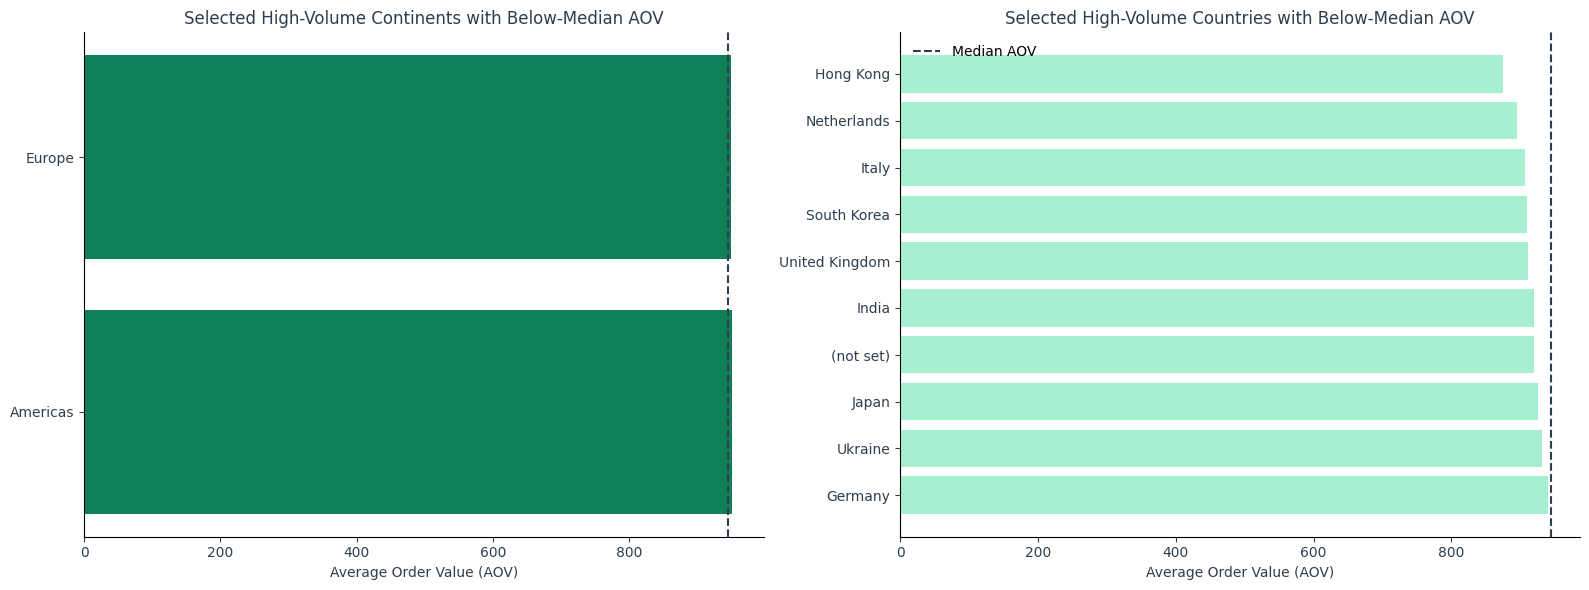

In [ ]:
median_aov = country_perf["aov"].median()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    low_value_continents.index,
    low_value_continents["aov"],
    color=TEAL_DARK
)
axes[0].set_title(
    "Selected High-Volume Continents with Below-Median AOV",
    color=DARK_BLUE
)
axes[0].set_xlabel(
    "Average Order Value (AOV)",
    color=DARK_BLUE
)

axes[0].axvline(
    median_aov,
    linestyle="--",
    color=DARK_BLUE,
    linewidth=1.5,
    label="Median AOV"
)
axes[0].invert_yaxis()

axes[0].tick_params(axis="x", colors=DARK_BLUE)
axes[0].tick_params(axis="y", colors=DARK_BLUE)

for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)


axes[1].barh(
    low_value_countries.index,
    low_value_countries["aov"],
    color=TEAL_LIGHT
)

axes[1].set_title(
    "Selected High-Volume Countries with Below-Median AOV",
    color=DARK_BLUE
)
axes[1].set_xlabel(
    "Average Order Value (AOV)",
    color=DARK_BLUE
)
axes[1].invert_yaxis()

axes[1].axvline(
    median_aov,
    linestyle="--",
    color=DARK_BLUE,
    linewidth=1.5,
    label="Median AOV"
)
axes[1].legend(frameon=False)
axes[1].tick_params(axis="x", colors=DARK_BLUE)
axes[1].tick_params(axis="y", colors=DARK_BLUE)

for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


EN:
High order volume in Asia combined with below-average AOV suggests monetization challenges rather than demand issues.

UA:
Висока кількість замовлень в Азії при нижчому за середній AOV свідчить про проблеми монетизації, а не нестачу попиту.

### Finding

EN:
Several regions demonstrate high order volume combined with below-average average order value (AOV). This indicates that demand exists, but revenue is driven primarily by transaction volume rather than value per order. Revenue growth in these regions is more likely to be achieved through monetization-focused initiatives—such as pricing adjustments, product mix optimization, or bundling—rather than additional traffic acquisition.

UA:
Деякі регіони мають високу кількість замовлень при нижчому за середній середньому чеку (AOV). Це свідчить про наявність попиту, однак дохід формується переважно за рахунок обсягу транзакцій, а не їхньої вартості. Зростання доходу в цих регіонах доцільніше досягати через ініціативи з підвищення монетизації (оптимізація цін, асортименту, бандли), а не за рахунок подальшого залучення трафіку.



##Sales performance by Сategory

**Question:**  
**EN:** Which categories generate the most revenue, and are there any categories with high demand but low monetization?

**UA:** Які категорії приносять найбільший дохід, і чи є категорії з високим попитом, але низькою монетизацією?

The following SQL query calculates category-level business metrics including order volume, total revenue, average order value (AOV), and revenue share using window functions.

In [ ]:
df_category_metrics = (
    df
    .groupby("category")
    .agg(
        orders_count=("ga_session_id", "nunique"),
        total_revenue=("price", "sum")
    )
    .reset_index()
)

df_category_metrics["aov"] = (
    df_category_metrics["total_revenue"]
    / df_category_metrics["orders_count"]
)

total_revenue_sum = df_category_metrics["total_revenue"].sum()

df_category_metrics["revenue_share"] = (
    df_category_metrics["total_revenue"] / total_revenue_sum
)

df_category_enriched = (
    df_category_metrics
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

df_category_metrics

,category,orders_count,total_revenue,aov,revenue_share
0,Bar furniture,1019,678653.0,665.999019,0.022675
1,Beds,2729,4603169.0,1686.760352,0.153799
2,Bookcases & shelving units,7138,3415223.9,478.456697,0.114108
3,Cabinets & cupboards,2185,2210072.5,1011.474828,0.073842
4,Café furniture,337,129127.0,383.166172,0.004314
5,Chairs,5611,5782126.6,1030.498414,0.193190
6,Chests of drawers & drawer units,1348,836965.0,620.893917,0.027964
7,Children's furniture,1597,438993.0,274.886036,0.014667
8,Nursery furniture,368,131487.0,357.301630,0.004393
9,Outdoor furniture,2091,1992297.6,952.796557,0.066566


Category-level metrics were calculated using pandas, including order count, total revenue, AOV, and revenue share.

Показники на рівні категорій були розраховані за допомогою pandas, включаючи кількість замовлень, загальний дохід, середню вартість замовлення (AOV) та частку доходу.

In [ ]:
weighted_aov = (
    df_category_metrics["total_revenue"].sum() /
    df_category_metrics["orders_count"].sum()
)
df_lolli = df_category_metrics.sort_values("orders_count", ascending=True).reset_index(drop=True)
y_pos = np.arange(len(df_lolli))

EN:
A weighted AOV was used to account for category revenue impact and avoid distortion from low-volume categories.

UA:
Для коректної оцінки було використано зважений AOV, щоб уникнути спотворення результатів через маловпливові категорії.

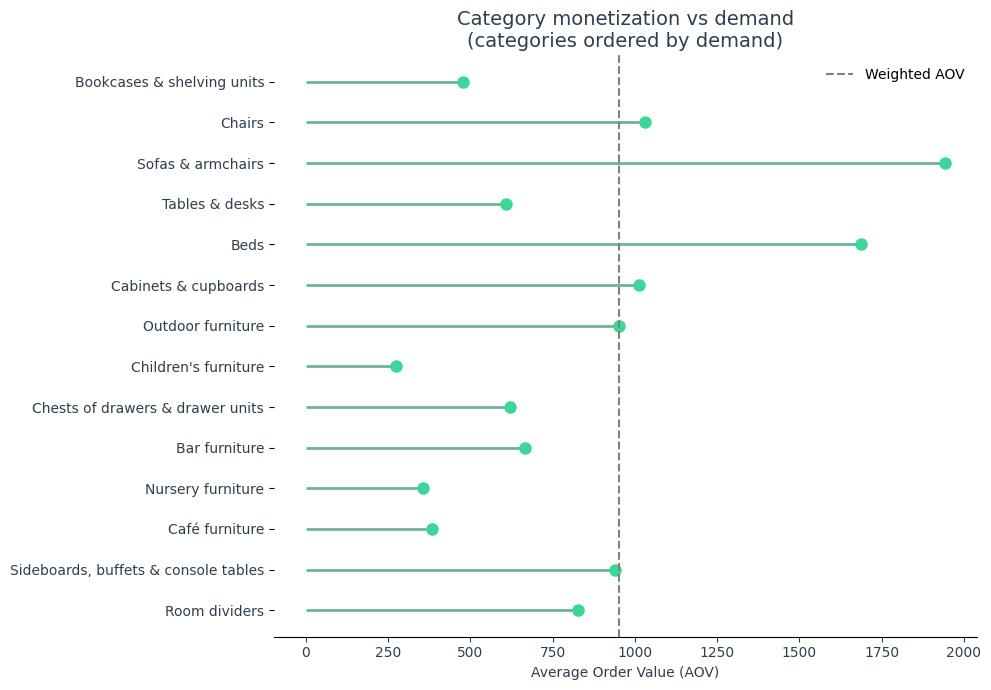

In [ ]:
plt.figure(figsize=(10, 7))

plt.hlines(
    y=y_pos,
    xmin=0,
    xmax=df_lolli["aov"],
    color=TEAL_DARK,
    alpha=0.6,
    linewidth=2
)

plt.plot(
    df_lolli["aov"],
    y_pos,
    "o",
    color=TEAL_CENTER,
    markersize=8
)

plt.axvline(
    weighted_aov,
    linestyle="--",
    label="Weighted AOV",
    color="gray"
    )

plt.yticks(
    y_pos,
    df_lolli["category"],
    color=DARK_BLUE
)

plt.xlabel("Average Order Value (AOV)", color=DARK_BLUE)
plt.title(
    "Category monetization vs demand\n(categories ordered by demand)",
    color=DARK_BLUE,
    fontsize=14
)

plt.tick_params(axis="x", colors=DARK_BLUE)

for spine in ["top", "right", "left"]:
    plt.gca().spines[spine].set_visible(False)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()


### Findings

EN:
While categories such as Beds and Sofas & Armchairs combine high demand with strong monetization, several high-demand categories operate below the weighted average AOV. This suggests that lower revenue contribution is driven by under-monetization rather than lack of customer interest. High-demand, low-AOV categories represent high-impact optimization opportunities. Even modest improvements in pricing, upsell strategies, or product bundles could result in immediate revenue uplift without increasing traffic.

UA:
Хоча такі категорії, як Beds та Sofas & Armchairs, поєднують високий попит із сильною монетизацією, кілька категорій з високим попитом мають AOV нижче зваженого середнього. Це вказує на недостатню монетизацію, а не на низький інтерес з боку клієнтів. Категорії з високим попитом та низьким AOV є пріоритетними для оптимізації. Навіть незначне підвищення середнього чеку через ціноутворення, апсел або бандли може швидко збільшити дохід без додаткового трафіку.


In [ ]:
revenue_drivers = (
    df_category_metrics
    .sort_values("total_revenue", ascending=False)
    .head(5)
    [["category", "total_revenue", "revenue_share"]]
)

revenue_drivers

,category,total_revenue,revenue_share
12,Sofas & armchairs,7828608.5,0.261566
5,Chairs,5782126.6,0.193190
1,Beds,4603169.0,0.153799
2,Bookcases & shelving units,3415223.9,0.114108
3,Cabinets & cupboards,2210072.5,0.073842


In [ ]:
orders_median = df_category_metrics["orders_count"].median()
aov_median = df_category_metrics["aov"].median()

df_category_metrics["segment"] = "Other"

df_category_metrics.loc[
    (df_category_metrics["orders_count"] >= orders_median) &
    (df_category_metrics["aov"] < aov_median),
    "segment"
] = "High demand / Low monetization"


Categories were segmented using median values of order volume and AOV.
Categories with high demand but below-median AOV were classified as “High demand / Low monetization”, indicating strong improvement potential.

Категорії були сегментовані з використанням медіанних значень обсягу замовлення та AOV.
Категорії з високим попитом, але нижче медіани AOV були класифіковані як "Високий попит/низька монетизація", що вказує на значний потенціал покращення.

In [ ]:
under_monetized = df_category_metrics[df_category_metrics["segment"] == "High demand / Low monetization"]

under_monetized[["category", "orders_count", "aov", "total_revenue"]]


,category,orders_count,aov,total_revenue
2,Bookcases & shelving units,7138,478.456697,3415223.9
13,Tables & desks,2760,609.161594,1681286.0


In [ ]:
set(revenue_drivers["category"]) & set(under_monetized["category"])

{'Bookcases & shelving units'}

Bookcases & shelving units category are also among top revenue drivers, making them high-impact optimization targets.

Категорія книжкових шаф і стелажів також є однією з основних джерел доходу, що робить їх важливими об'єктами оптимізації.

In [ ]:
summary = (
    df_category_metrics
    .assign(is_revenue_driver=df_category_metrics["category"].isin(revenue_drivers["category"]))
    .query("segment == 'High demand / Low monetization'")
    [["category", "orders_count", "aov", "total_revenue", "is_revenue_driver"]]
)
summary

,category,orders_count,aov,total_revenue,is_revenue_driver
2,Bookcases & shelving units,7138,478.456697,3415223.9,True
13,Tables & desks,2760,609.161594,1681286.0,False


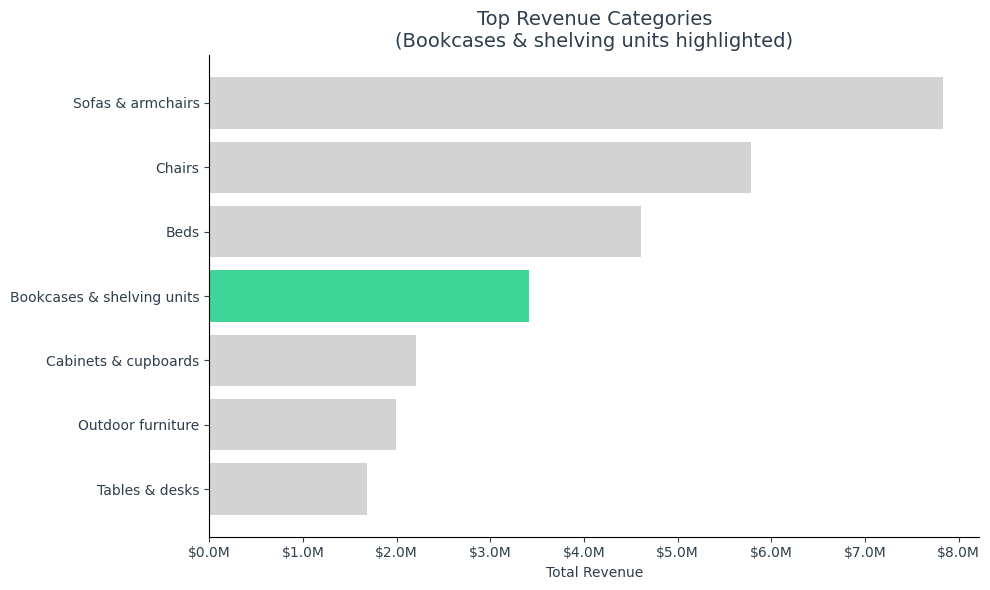

In [ ]:
import matplotlib.ticker as mtick

def format_millions(x):
    return f'${x*1e-6:,.1f}M'

df_rev = (
    df_category_metrics
    .sort_values("total_revenue", ascending=False)
    .head(7)
)

colors = [
    TEAL_CENTER if c == "Bookcases & shelving units" else GREY_LIGHT
    for c in df_rev["category"]
]

plt.figure(figsize=(10, 6))
plt.barh(
    df_rev["category"],
    df_rev["total_revenue"],
    color=colors
)

plt.xlabel("Total Revenue", color=DARK_BLUE)
plt.title(
    "Top Revenue Categories\n(Bookcases & shelving units highlighted)",
    color=DARK_BLUE,
    fontsize=14
)

plt.tick_params(axis="both", colors=DARK_BLUE)
plt.gca().invert_yaxis()

ax = plt.gca()
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: format_millions(x))
)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

###Finding

EN:
Categories classified as high demand but low monetization generate a substantial number of orders while underperforming in average order value, highlighting a monetization gap rather than a demand issue. These categories should be prioritized for targeted monetization experiments, such as price testing, bundle offers, or cross-sell initiatives, before allocating additional marketing spend.

UA:
Категорії, класифіковані як високопопитні з низькою монетизацією, генерують значну кількість замовлень, але мають нижчий середній чек, що вказує на розрив у монетизації, а не на проблему попиту. Ці категорії варто зробити пріоритетними для монетизаційних експериментів (A/B тестування цін, бандли, крос-сейл) перед інвестуванням у додатковий маркетинговий трафік.


##Sales performance by Сhannel

**Question:**

**EN:** Which channels generate revenue, and which drive traffic with low business value?

**UA:** Які канали приносять дохід, а які привертають трафік з низькою бізнес-цінністю?

In [ ]:
channel_metrics = (
    df
    .groupby("traffic_source")
    .agg(
        sessions=("ga_session_id", "nunique"),
        revenue=("price", "sum")
    )
    .assign(revenue_per_session=lambda x: x["revenue"] / x["sessions"])
    .reset_index()
)
channel_metrics_plot = channel_metrics[
    channel_metrics["traffic_source"] != "Data Removed"
]


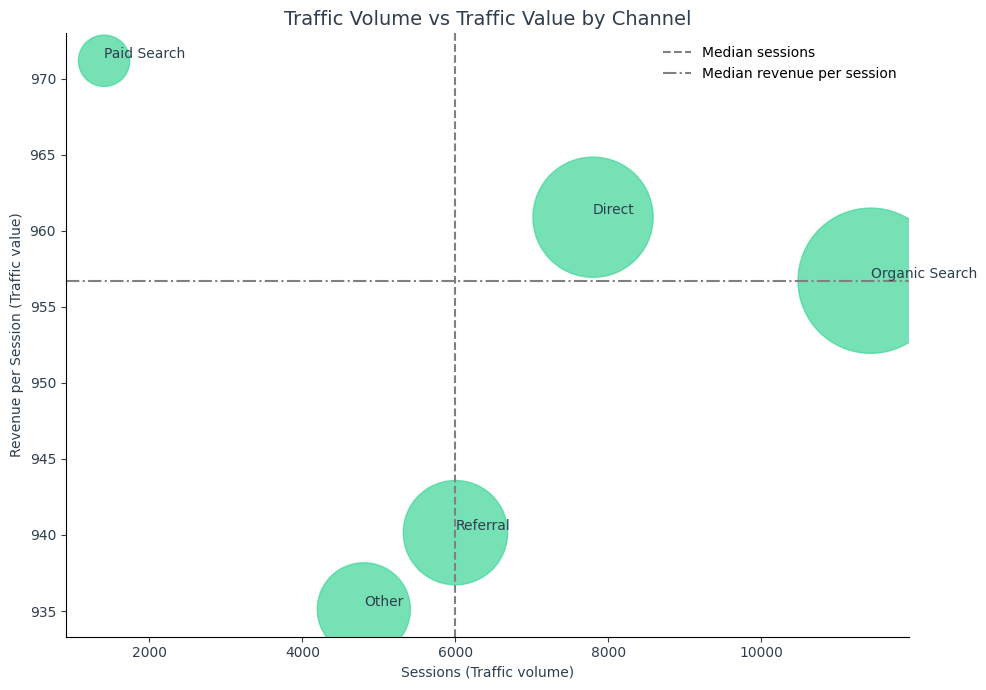

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    channel_metrics_plot["sessions"],
    channel_metrics_plot["revenue_per_session"],
    s=channel_metrics_plot["revenue"] / 1000,
    color=TEAL_CENTER,
    alpha=0.7
)

for _, row in channel_metrics_plot.iterrows():
    plt.text(
        row["sessions"],
        row["revenue_per_session"],
        row["traffic_source"],
        fontsize=10,
        color=DARK_BLUE,
        ha="left",
        va="bottom"
    )

sessions_median = channel_metrics_plot["sessions"].median()
value_median = channel_metrics_plot["revenue_per_session"].median()

plt.axvline(
    sessions_median,
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Median sessions"
)

plt.axhline(
    value_median,
    linestyle='dashdot',
    color="gray",
    linewidth=1.5,
    label="Median revenue per session"
)

plt.xlabel("Sessions (Traffic volume)", color=DARK_BLUE)
plt.ylabel("Revenue per Session (Traffic value)", color=DARK_BLUE)
plt.title(
    "Traffic Volume vs Traffic Value by Channel",
    color=DARK_BLUE,
    fontsize=14
)

plt.tick_params(axis="both", colors=DARK_BLUE)
plt.legend(frameon=False)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


###Findings

EN:
Organic Search and Direct channels combine high traffic volume with above-median revenue per session, making them the primary revenue drivers. In contrast, Paid Search and Other channels generate traffic with below-median revenue efficiency. Growth efforts should prioritize scaling Organic Search and Direct channels, while optimization initiatives for Referral and Other channels should focus on conversion rate and basket size improvements rather than traffic growth.

UA:
Канали Organic Search та Direct поєднують високий обсяг трафіку з доходом на сесію вище медіанного, що робить їх основними драйверами доходу. Натомість Paid Search та Other генерують трафік з нижчою ефективністю доходу. Зусилля зі зростання варто зосередити на масштабуванні Organic Search та Direct, тоді як для каналів Referral та Other доцільніше фокусуватися на підвищенні конверсії та середнього чеку, а не на зростанні трафіку.


##Sales performance by Subscription/Unsubscription Status

**Question:**  
**EN:** Does email subscription impact actual sales, and is email marketing a worthwhile investment?

**UA:** Чи впливає підписка на електронну пошту на фактичні продажі, і чи є електронний маркетинг вигідною інвестицією?

In [ ]:
email_df = df[df["registered_user_id"].notna()].copy()

email_df["email_status"] = email_df["is_unsubscribed"].apply(
    lambda x: "Unsubscribed" if x == 1 else "Subscribed"
)

email_df["email_status"].value_counts(dropna=False)

email_metrics = (
    email_df
    .groupby("email_status")
    .agg(
        users=("registered_user_id", "nunique"),
        sessions=("ga_session_id", "nunique"),
        orders=("price", "count"),
        total_revenue=("price", "sum"),
        aov=("price", "mean")
    )
    .assign(
        revenue_per_user=lambda x: x["total_revenue"] / x["users"]
    )
    .reset_index()
)
email_metrics

,email_status,users,sessions,orders,total_revenue,aov,revenue_per_user
0,Subscribed,2173,2173,2173,1983396.6,912.745789,912.745789
1,Unsubscribed,421,421,421,405049.6,962.113064,962.113064


In [ ]:
email_df["email_status"].value_counts()


,count
email_status,
Subscribed,2173
Unsubscribed,421


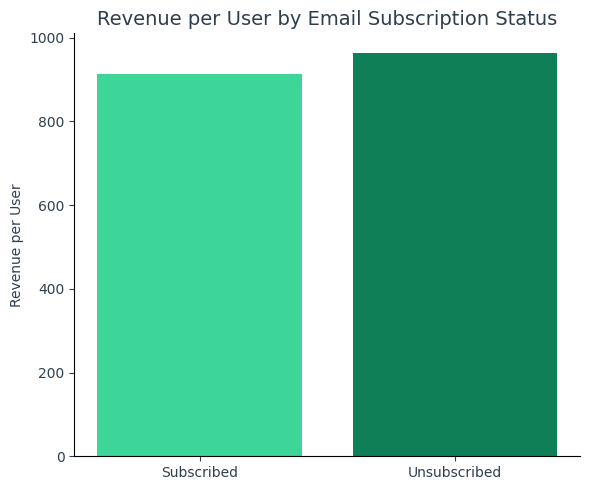

In [ ]:
plt.figure(figsize=(6, 5))

plt.bar(
    email_metrics["email_status"],
    email_metrics["revenue_per_user"],
    color=[TEAL_CENTER, TEAL_DARK]
)

plt.ylabel("Revenue per User", color=DARK_BLUE)
plt.title(
    "Revenue per User by Email Subscription Status",
    color=DARK_BLUE,
    fontsize=14
)

plt.tick_params(axis="both", colors=DARK_BLUE)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Finding

**EN:**
Subscribed users demonstrate higher purchase values compared to unsubscribed users. However, this difference reflects correlation rather than causal impact and may be influenced by self-selection of more engaged users. Email marketing appears to be associated with higher user value, but its direct impact cannot be confirmed without controlled experimentation. Further analysis using cohort tracking or A/B testing is required before scaling email-driven initiatives.


**UA:**
Підписані користувачі демонструють вищі показники покупок порівняно з відписаними. Водночас ця різниця відображає кореляцію, а не причинний вплив, і може бути зумовлена самовідбором більш залучених користувачів. Email-маркетинг асоціюється з вищою цінністю користувачів, однак його прямий вплив не може бути підтверджений без контрольованих експериментів. Перед масштабуванням email-ініціатив доцільно провести когортний аналіз або A/B тестування.

##Sales performance by Device type

**Question**:

**EN:** How is revenue distributed across device types, and does AOV differ between them?

**UA:** Як розподіляються доходи між типами пристроїв і чи відрізняється середня вартість замовлення між ними?

**EN:** This analysis helps identify monetization gaps across devices.

**UA:** Цей аналіз допомагає виявити розбіжності в монетизації між різними пристроями.

In [ ]:
device_metrics = (
    df
    .groupby("device")
    .agg(
        orders=("ga_session_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
)

device_metrics["aov"] = (
    device_metrics["revenue"] / device_metrics["orders"]
)

device_metrics["revenue_share"] = (
    device_metrics["revenue"] / device_metrics["revenue"].sum() * 100
)

device_metrics = device_metrics.sort_values("revenue_share", ascending=False)

device_metrics

,device,orders,revenue,aov,revenue_share
0,desktop,18497,17659936.8,954.746002,59.004507
1,mobile,12265,11610655.9,946.649482,38.792949
2,tablet,679,659217.4,970.865096,2.202545


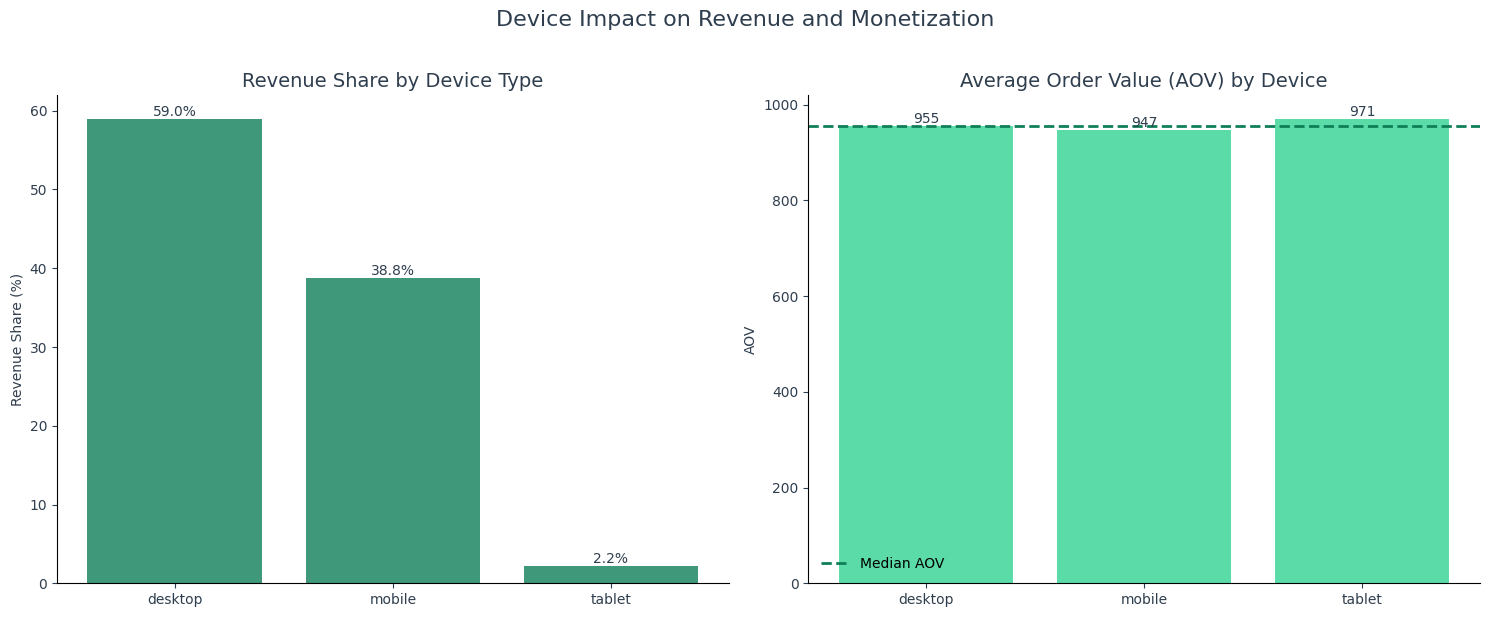

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(
    device_metrics["device"],
    device_metrics["revenue_share"],
    color=TEAL_DARK,
    alpha=0.8
)

axes[0].set_title(
    "Revenue Share by Device Type",
    color=DARK_BLUE,
    fontsize=14
)
axes[0].set_ylabel("Revenue Share (%)", color=DARK_BLUE)

axes[0].tick_params(axis="x", colors=DARK_BLUE)
axes[0].tick_params(axis="y", colors=DARK_BLUE)


for i, value in enumerate(device_metrics["revenue_share"]):
    axes[0].text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        color=DARK_BLUE,
        fontsize=10
    )

for spine in ["top", "right"]:
    axes[0].spines[spine].set_visible(False)


axes[1].bar(
    device_metrics["device"],
    device_metrics["aov"],
    color=TEAL_CENTER,
    alpha=0.85
)

axes[1].set_title(
    "Average Order Value (AOV) by Device",
    color=DARK_BLUE,
    fontsize=14
)
axes[1].set_ylabel("AOV", color=DARK_BLUE)

axes[1].tick_params(axis="x", colors=DARK_BLUE)
axes[1].tick_params(axis="y", colors=DARK_BLUE)


aov_median = device_metrics["aov"].median()
axes[1].axhline(
    aov_median,
    linestyle="--",
    color=TEAL_DARK,
    linewidth=2,
    label="Median AOV"
)

for i, value in enumerate(device_metrics["aov"]):
    axes[1].text(
        i,
        value,
        f"{value:.0f}",
        ha="center",
        va="bottom",
        color=DARK_BLUE,
        fontsize=10
    )

axes[1].legend(frameon=False)

for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

plt.suptitle(
    "Device Impact on Revenue and Monetization",
    color=DARK_BLUE,
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


###Finding

**EN:**
Desktop dominates total revenue (59%) and shows a stable AOV close to the median, making it the primary revenue driver.
Mobile contributes a substantial share of revenue (39%) but with slightly lower AOV, indicating potential monetization gaps.
Tablet shows the highest AOV but negligible revenue share, suggesting low transaction volume rather than strong monetization. Revenue growth should primarily focus on desktop and mobile devices.
Mobile represents the strongest monetization opportunity through checkout optimization, pricing, and upsell mechanics.
Tablet traffic does not justify dedicated optimization efforts due to its minimal contribution to total revenue.

**UA:**
Desktop є основним драйвером доходу (59%) зі стабільним AOV поблизу медіани.
Mobile формує значну частку доходу (39%), але з дещо нижчим AOV, що вказує на потенціал для покращення монетизації.
Tablet має найвищий AOV, однак мінімальну частку доходу, що свідчить радше про малу кількість замовлень, а не про сильну монетизацію. Зростання доходу варто фокусувати насамперед на desktop і mobile.
Mobile — найперспективніший напрям для підвищення монетизації через оптимізацію checkout, цін і апселів.
Оптимізація tablet не є пріоритетною через його незначний внесок у загальний дохід.


#Dynamics

##Revenue Dynamics & Seasonal Risk Analysis

**Question:**
During which periods does the business experience revenue decline, and when should marketing efforts be intensified or strategy adjusted?

In [ ]:
daily_metrics = (
    df
    .groupby("date")
    .agg(
        revenue=("price", "sum"),
        orders=("ga_session_id", "nunique")
    )
    .assign(
        aov=lambda x: x["revenue"] / x["orders"]
    )
    .reset_index()
    .sort_values("date")
)

daily_metrics.head()

,date,revenue,orders,aov
0,2020-11-01,239372.5,267,896.526217
1,2020-11-02,330931.8,340,973.328824
2,2020-11-03,465330.2,519,896.589981
3,2020-11-04,321340.1,340,945.117941
4,2020-11-05,352815.2,349,1010.931805


In [ ]:
daily_metrics["revenue_7d_avg"] = (
    daily_metrics["revenue"]
    .rolling(window=7, min_periods=1)
    .mean()
)

daily_metrics["orders_7d_avg"] = (
    daily_metrics["orders"]
    .rolling(window=7, min_periods=1)
    .mean()
)

daily_metrics["weekday"] = daily_metrics["date"].dt.day_name()
daily_metrics["month"] = daily_metrics["date"].dt.to_period("M").astype(str)

daily_metrics

,date,revenue,orders,aov,revenue_7d_avg,orders_7d_avg,weekday,month
0,2020-11-01,239372.5,267,896.526217,239372.500000,267.000000,Sunday,2020-11
1,2020-11-02,330931.8,340,973.328824,285152.150000,303.500000,Monday,2020-11
2,2020-11-03,465330.2,519,896.589981,345211.500000,375.333333,Tuesday,2020-11
3,2020-11-04,321340.1,340,945.117941,339243.650000,366.500000,Wednesday,2020-11
4,2020-11-05,352815.2,349,1010.931805,341957.960000,363.000000,Thursday,2020-11
...,...,...,...,...,...,...,...,...
83,2021-01-23,275570.5,298,924.733221,350777.614286,373.285714,Saturday,2021-01
84,2021-01-24,231476.9,280,826.703214,337386.928571,364.285714,Sunday,2021-01
85,2021-01-25,294552.3,352,836.796307,329070.071429,364.857143,Monday,2021-01
86,2021-01-26,358722.3,361,993.690582,329528.885714,363.428571,Tuesday,2021-01


 EN: Use min_periods=1 to avoid NaN values at the beginning of the time series.

UA: Використовуємо min_periods=1, щоб уникнути NaN на початку часової серії.


EN:
A 7-day rolling average was applied to smooth short-term fluctuations in daily revenue and highlight underlying trends.
Weekday and monthly features were extracted to analyze seasonality patterns in sales performance.

UA:
7-денне ковзне середнє було використано для згладжування короткострокових коливань щоденних продажів та виявлення загального тренду.
Було виокремлено характеристики по днях тижня та місяцях для аналізу сезонних закономірностей у динаміці продажів.

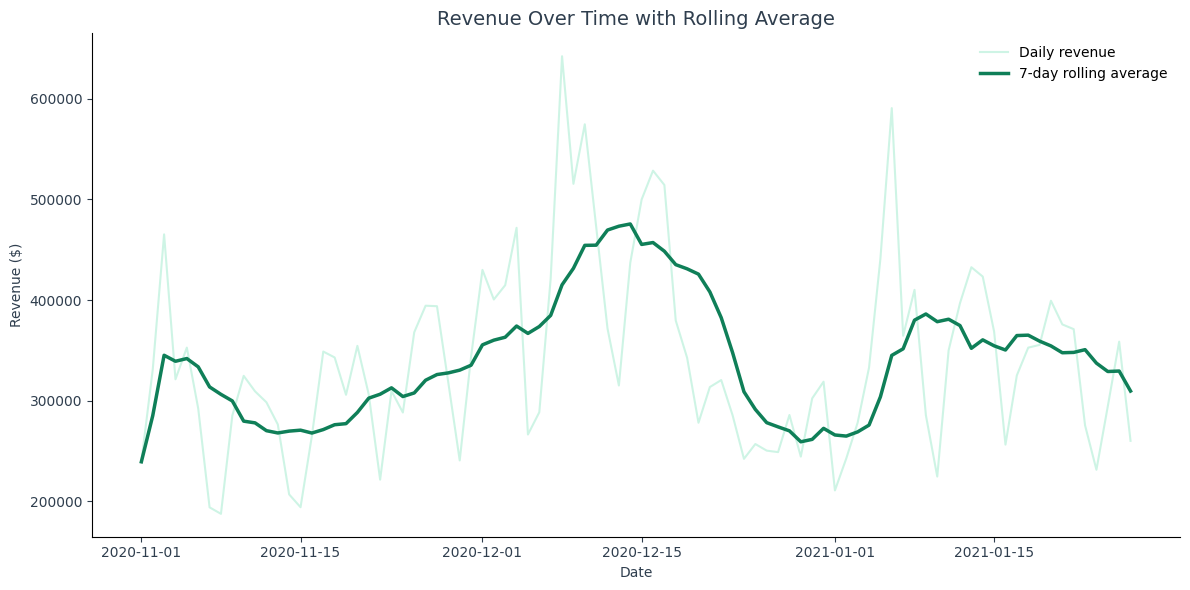

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_metrics["date"],
    daily_metrics["revenue"],
    color=TEAL_CENTER,
    alpha=0.25,
    label="Daily revenue"
)

plt.plot(
    daily_metrics["date"],
    daily_metrics["revenue_7d_avg"],
    color=TEAL_DARK,
    linewidth=2.5,
    label="7-day rolling average"
)

plt.title(
    "Revenue Over Time with Rolling Average",
    color=DARK_BLUE,
    fontsize=14
)
plt.xlabel("Date", color=DARK_BLUE)
plt.ylabel("Revenue ($)", color=DARK_BLUE)

plt.tick_params(axis="both", colors=DARK_BLUE)
plt.legend(frameon=False)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


EN: The chart shows daily revenue dynamics along with a 7-day rolling average to smooth short-term fluctuations.
While daily revenue exhibits high volatility, the rolling average highlights underlying trends and potential periods of sustained decline.

UA:
На графіку показано динаміку щоденних доходів разом із 7-денним ковзним середнім значенням для згладжування короткострокових коливань.
Хоча щоденні доходи демонструють високу волатильність, ковзне середнє значення висвітлює основні тенденції та потенційні періоди стійкого зниження.


In [ ]:
seasonality_weekday = (
    daily_metrics
    .groupby("weekday")
    .agg(
        revenue=("revenue", "mean"),
        orders=("orders", "mean"),
        aov=("aov", "mean")
    )
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
)

seasonality_month = (
    daily_metrics
    .assign(month=daily_metrics["date"].dt.to_period("M"))
    .groupby("month")
    .agg(
        revenue=("revenue", "sum"),
        orders=("orders", "sum"),
        aov=("aov", "mean")
    )
)

monthly_avg = seasonality_month["revenue"].mean()
below_avg = seasonality_month["revenue"] < monthly_avg

seasonality_weekday

,revenue,orders,aov
weekday,,,
Monday,332561.500000,356.923077,936.472655
Tuesday,393617.992308,416.923077,940.954630
Wednesday,389035.684615,401.307692,966.468752
Thursday,381725.991667,388.416667,986.471193
Friday,355008.191667,359.083333,995.238955
Saturday,276407.650000,294.166667,941.144732
Sunday,251870.061538,281.846154,892.765123


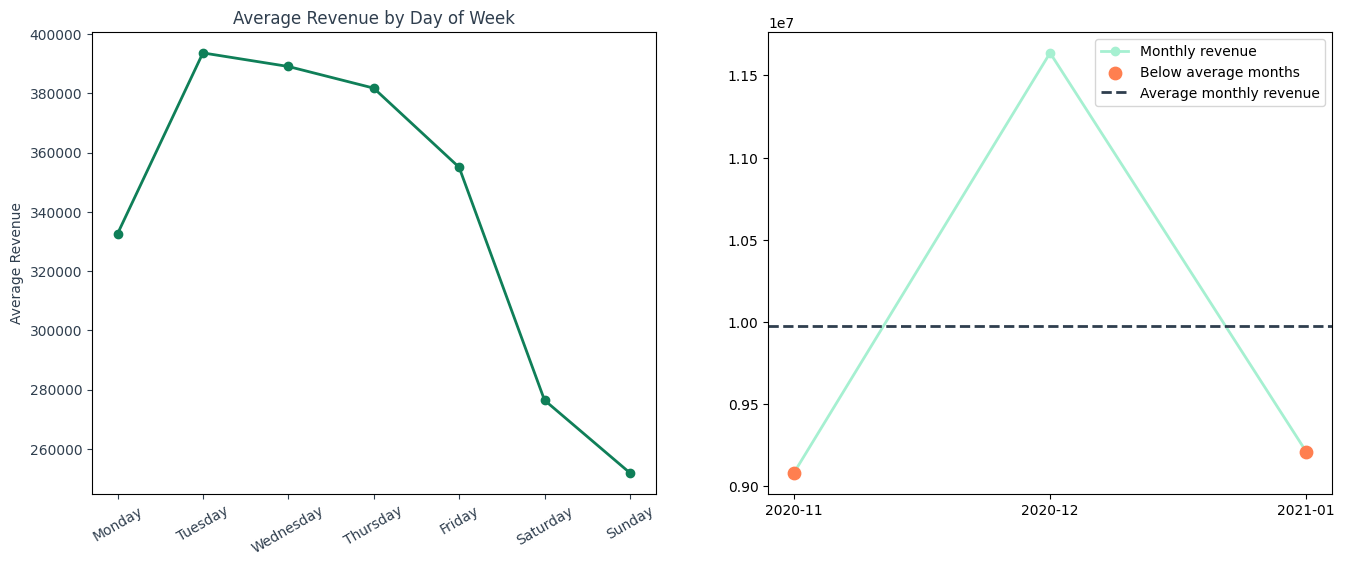

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(
    seasonality_weekday.index,
    seasonality_weekday["revenue"],
    color=TEAL_DARK,
    marker="o",
    linewidth=2
)

axes[0].set_title(
    "Average Revenue by Day of Week",
    color=DARK_BLUE
)
axes[0].set_ylabel(
    "Average Revenue",
    color=DARK_BLUE
)

axes[0].tick_params(axis="x", rotation=30, colors=DARK_BLUE)
axes[0].tick_params(axis="y", colors=DARK_BLUE)

axes[1].plot(
    seasonality_month.index.astype(str),
    seasonality_month["revenue"],
    color=TEAL_LIGHT,
    marker="o",
    linewidth=2,
    label="Monthly revenue"
)

axes[1].scatter(
    seasonality_month.index.astype(str)[below_avg],
    seasonality_month["revenue"][below_avg],
    color="coral",
    s=80,
    label="Below average months",
    zorder=3
)


axes[1].axhline(
    monthly_avg,
    linestyle="--",
    color=DARK_BLUE,
    linewidth=2,
    label="Average monthly revenue"
)

axes[1].legend()

**EN:**
Monthly values are based on aggregated daily revenue. Partial months may distort the trend and were excluded from interpretation.

**UA:**
Місячні значення розраховані на основі щоденних даних. Неповні місяці можуть спотворювати тренд і не враховувалися при інтерпретації.


### Finding
**EN:**
Revenue shows clear short-term volatility with an identifiable underlying trend. The 7-day rolling average highlights periods of growth and decline, suggesting demand-driven fluctuations rather than random noise.
Weekly seasonality is evident, with weekdays consistently outperforming weekends. Monthly patterns indicate variability across months, though interpretation is limited due to partial data coverage. Marketing and operational efforts should be intensified during high-performing weekdays, while weekends may require targeted promotions or pricing incentives.
Understanding short-term revenue drops enables proactive planning of campaigns and inventory adjustments. Rolling-average trends can be used as an early-warning signal for demand slowdowns and to optimize budget allocation over time.

**UA:**
Продажі характеризуються короткостроковими коливаннями, але при цьому мають чіткий загальний тренд. 7-денне ковзне середнє демонструє періоди зростання та спаду, що свідчить про зміну попиту, а не випадкові коливання.
Спостерігається тижнева сезонність: будні стабільно приносять більше доходу, ніж вихідні. Місячна динаміка показує відмінності між місяцями, однак інтерпретація обмежена через неповні дані. Маркетингові та операційні активності доцільно посилювати у дні з найвищими продажами, тоді як для вихідних варто розглянути спеціальні акції або цінові стимули.
Аналіз короткострокових спадів доходу дозволяє завчасно планувати кампанії та коригувати запаси. Ковзне середнє може використовуватися як інструмент раннього виявлення спаду попиту та оптимізації бюджету.


##Sales Dynamics by Continent

**Question:**
Do revenue trends differ across continents, and do declines happen at the same time?

**EN:**
Daily revenue is aggregated by continent to analyze regional sales dynamics over time.

**UA:**
Щоденний дохід агреговано за континентами для аналізу регіональної динаміки продажів у часі.


In [ ]:
continent_time_metrics = (
    df
    .groupby(["date", "continent"])
    .agg(
        revenue=("price", "sum")
    )
    .reset_index()
)

continent_time_metrics["revenue_7d_avg"] = (
    continent_time_metrics
    .groupby("continent")["revenue"]
    .rolling(window=7, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)



**EN:** Apply a 7-day rolling average per continent to reduce daily noise.

**UA**: Застосовуємо 7-денне ковзне середнє по кожному континенту для зменшення шуму.


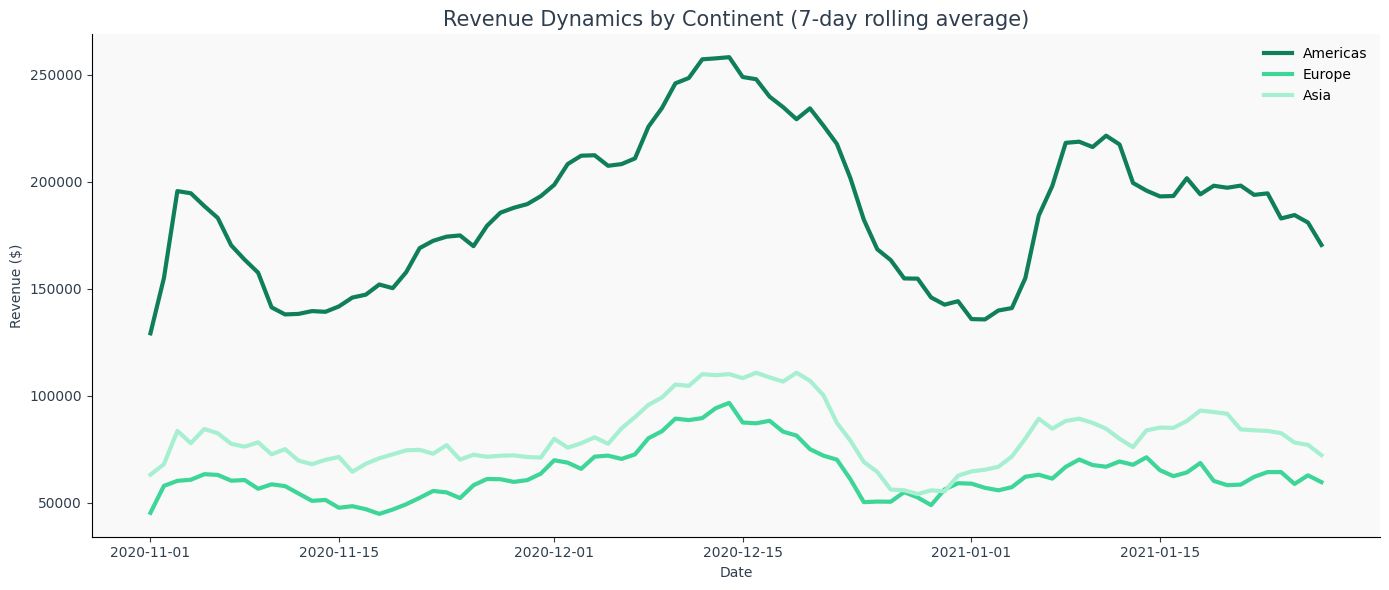

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor("#f9f9f9")

continent_colors = {
    "Americas": TEAL_DARK,
    "Europe": TEAL_CENTER,
    "Asia": TEAL_LIGHT
}

for continent, color in continent_colors.items():
    data = continent_time_metrics[
        continent_time_metrics["continent"] == continent
    ]

    ax.plot(
        data["date"],
        data["revenue_7d_avg"],
        label=continent,
        color=color,
        linewidth=3
    )

ax.set_title(
    "Revenue Dynamics by Continent (7-day rolling average)",
    color=DARK_BLUE,
    fontsize=15
)

ax.set_ylabel("Revenue ($)", color=DARK_BLUE)
ax.set_xlabel("Date", color=DARK_BLUE)


ax.tick_params(axis="x", colors=DARK_BLUE)
ax.tick_params(axis="y", colors=DARK_BLUE)

ax.legend(frameon=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


### Finding
**EN:** Revenue trends across Americas, Europe, and Asia show largely synchronized patterns, indicating strong global demand drivers rather than region-specific effects. While all regions experience similar peaks and declines, Asia demonstrates higher volatility with sharper short-term fluctuations. Americas and Europe exhibit more stable revenue dynamics over time. Since revenue declines tend to occur simultaneously across continents, global-level demand shocks should be prioritized over region-specific interventions. Marketing and inventory planning can be coordinated globally, while Asia may require additional buffers due to higher volatility. Region-specific optimization is less critical than timing strategies aligned with global demand cycles.

**UA:**
Динаміка доходів в Америці, Європі та Азії є переважно синхронною, що вказує на глобальні фактори попиту, а не регіональні особливості. Водночас Азія характеризується вищою волатильністю та різкішими короткостроковими коливаннями. Америка та Європа демонструють більш стабільні продажі. Оскільки спади доходів відбуваються одночасно на різних континентах, основну увагу слід приділяти глобальним факторам попиту, а не локальним регіональним діям. Маркетингове та операційне планування можна координувати на глобальному рівні. Для Азії доцільно закладати додаткові буфери через вищу волатильність.


##Sales Dynamics by Channel

**Question:** How does revenue change over time across traffic channels, and which channels are more stable or risky?

**EN:** Aggregate daily revenue by traffic channel to analyze revenue dynamics over time.

**UA:** Агрегуємо щоденний дохід за каналами трафіку, щоб проаналізувати динаміку продажів у часі.


In [ ]:
channel_time_metrics = (
    df
    .groupby(["date", "traffic_source"])
    .agg(
        revenue=("price", "sum")
    )
    .reset_index()
)




**EN:** Use a 7-day rolling average to smooth daily fluctuations.

**UA:** Використовуємо 7-денне ковзне середнє, щоб згладити щоденні коливання.


In [ ]:
channel_time_metrics["revenue_7d_avg"] = (
    channel_time_metrics
    .groupby("traffic_source")["revenue"]
    .rolling(window=7, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

**EN:** Compare revenue trends across traffic channels.

**UA:** Порівнюємо динаміку доходів між різними каналами трафіку.


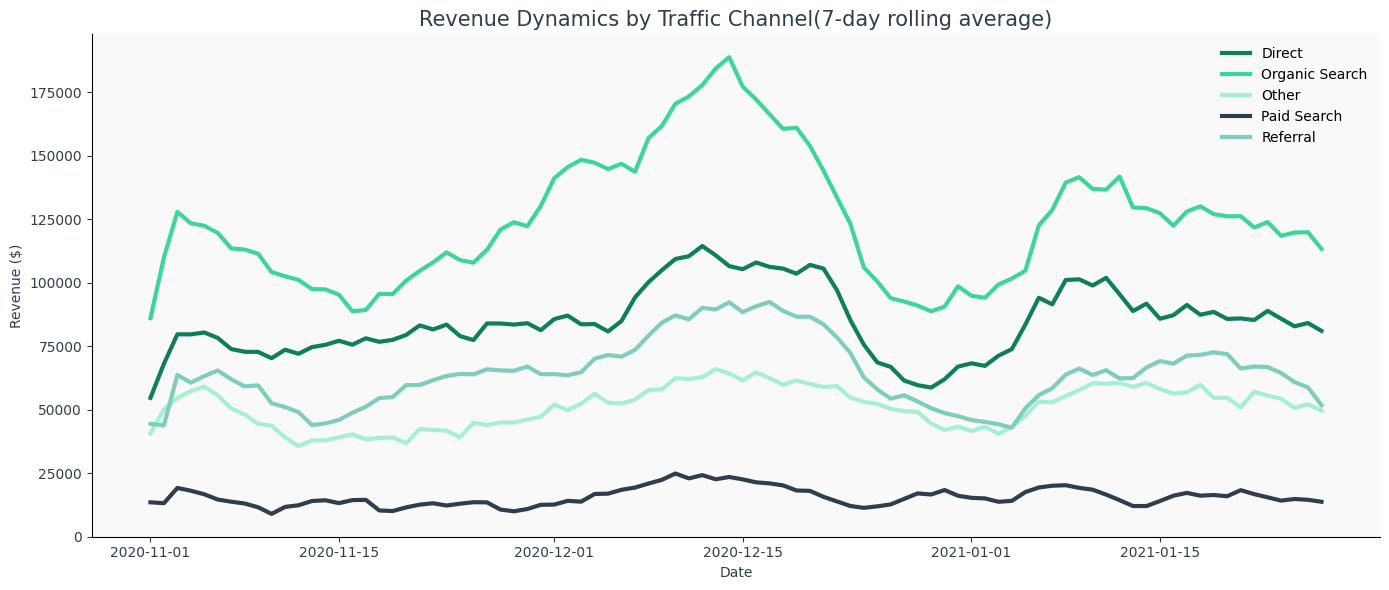

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor("#f9f9f9")

channels = channel_time_metrics["traffic_source"].unique()
colors = [TEAL_DARK, TEAL_CENTER, TEAL_LIGHT, DARK_BLUE, "#7FCDBB"]

for channel, color in zip(channels, colors):
    data = channel_time_metrics[
        channel_time_metrics["traffic_source"] == channel
    ]

    ax.plot(
        data["date"],
        data["revenue_7d_avg"],
        label=channel,
        color=color,
        linewidth=3
    )

ax.set_title(
    "Revenue Dynamics by Traffic Channel(7-day rolling average)",
    color=DARK_BLUE,
    fontsize=15
)
ax.set_xlabel("Date", color=DARK_BLUE)
ax.set_ylabel("Revenue ($)", color=DARK_BLUE)

ax.tick_params(axis="x", colors=DARK_BLUE)
ax.tick_params(axis="y", colors=DARK_BLUE)

ax.legend(frameon=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Finding
**EN:**
Organic Search and Direct channels generate the highest and most stable revenue over time. Paid Search brings lower revenue and shows more volatility. Referral and Other channels have smaller impact on total revenue. The business should focus on maintaining and growing Organic Search and Direct channels, as they bring the most value. Paid Search requires optimization, since it generates revenue but is less stable. Referral and Other channels are not key revenue drivers.

**UA:**
Канали Organic Search та Direct приносять найбільший і найбільш стабільний дохід. Paid Search генерує менше доходу та має більші коливання. Канали Referral та Other мають менший вплив на загальні продажі. Бізнесу варто зосередитись на розвитку каналів Organic Search та Direct, оскільки вони приносять найбільшу цінність. Paid Search потребує оптимізації, бо дає дохід, але менш стабільний. Канали Referral та Other не є ключовими драйверами доходу.


##Sales Dynamics by Devices
**Question:** Do different device types show different revenue trends and stability over time?

**EN:** Aggregate daily revenue by device type to analyze sales dynamics over time.

**UA:** Агрегуємо щоденний дохід за типами девайсів, щоб проаналізувати динаміку продажів у часі.


In [ ]:
device_time_metrics = (
    df
    .groupby(["date", "device"])
    .agg(
        revenue=("price", "sum")
    )
    .reset_index()
)

**EN:** Compare revenue trends across device types.

**UA:** Порівнюємо динаміку доходів між різними типами девайсів.


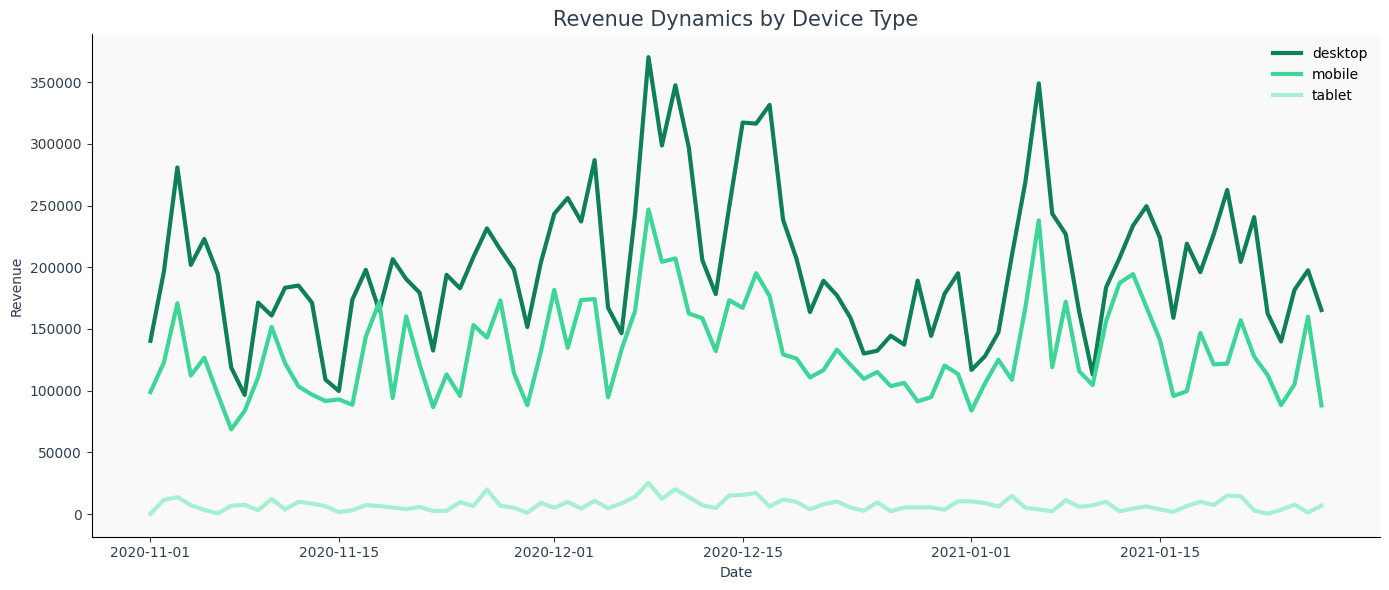

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor("#f9f9f9")

for device, color in zip(
    device_time_metrics["device"].unique(),
    [TEAL_DARK, TEAL_CENTER, TEAL_LIGHT]
):
    data = device_time_metrics[
        device_time_metrics["device"] == device
    ]

    ax.plot(
        data["date"],
        data["revenue"],
        label=device,
        color=color,
        linewidth=3
    )

ax.set_title(
    "Revenue Dynamics by Device Type",
    color=DARK_BLUE,
    fontsize=15
)
ax.set_xlabel("Date", color=DARK_BLUE)
ax.set_ylabel("Revenue", color=DARK_BLUE)

ax.tick_params(axis="x", colors=DARK_BLUE)
ax.tick_params(axis="y", colors=DARK_BLUE)

ax.legend(frameon=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


###Findings

**EN:** Desktop consistently generates the highest revenue over time. Mobile follows a similar trend but at a lower level. Tablet revenue remains minimal and shows no significant impact on overall sales dynamics. Desktop should remain the main focus for revenue-driven initiatives. Mobile represents a growth opportunity but requires better monetization. Tablet does not require active optimization due to its low contribution.

**UA:** Desktop стабільно генерує найбільший дохід. Mobile має схожий тренд, але з нижчим рівнем доходу. Tablet майже не впливає на загальні продажі. Основний фокус бізнесу варто залишити на desktop. Mobile має потенціал зростання, але потребує кращої монетизації. Tablet не потребує активної оптимізації через низький внесок у дохід.

#Pivot Table Analysis

##Sessions by Traffic Channel and Device Type

In [ ]:
df_sessions_clean = df[
    df["traffic_source"].notna() &
    df["device"].notna()
]

In [ ]:
pivot_sessions = pd.pivot_table(
    df_sessions_clean,
    values="ga_session_id",
    index="traffic_source",
    columns="device",
    aggfunc="nunique",
    fill_value=0
)

pivot_sessions_pct = pivot_sessions.div(pivot_sessions.sum(axis=1), axis=0) * 100
pivot_sessions_pct.round(1)

device,desktop,mobile,tablet
traffic_source,,,
Direct,59.7,38.3,2.1
Organic Search,59.0,38.9,2.1
Other,58.3,39.2,2.5
Paid Search,57.4,39.7,2.9
Referral,58.2,39.9,2.0


**EN:**
This table shows how sessions are distributed across device types within each traffic channel.

**UA:**
Ця таблиця показує, як сесії розподіляються між типами девайсів у межах кожного каналу трафіку


/tmp/ipykernel_2247/3700069020.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Device Type", frameon=False)


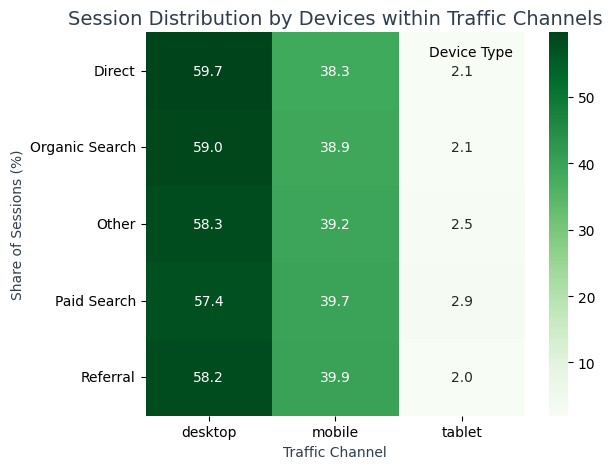

In [ ]:
sns.heatmap(
    pivot_sessions_pct,
    annot=True,
    fmt=".1f",
    cmap="Greens"
)

plt.title(
    "Session Distribution by Devices within Traffic Channels",
    color=DARK_BLUE,
    fontsize=14
)
plt.ylabel("Share of Sessions (%)", color=DARK_BLUE)
plt.xlabel("Traffic Channel", color=DARK_BLUE)
plt.legend(title="Device Type", frameon=False)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


###Finding

**EN:**
Organic Search and Direct channels have a strong mobile presence, while Paid Search is more desktop-oriented. Tablet traffic remains marginal across all channels. Mobile experience is critical for Organic Search and Direct channels. Paid Search performance should be optimized primarily for desktop users, while tablet optimization is not a priority.

**UA:**
Organic Search і Direct мають велику частку мобільного трафіку, тоді як Paid Search більше орієнтований на десктоп. Трафік з планшетів не є суттєвим для жодного каналу. Мобільний досвід є критичним для каналів Organic Search і Direct. Paid Search доцільно оптимізувати насамперед під десктоп. Оптимізація під планшети не є пріоритетною.

##Revenue by Product Category Across Top Countries

In [ ]:
top_countries = (
    df.groupby("country")
    .agg(total_revenue=("price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(5)
    .index
)

top_categories = (
    df.groupby("category")
    .agg(total_revenue=("price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .index
)

df_filtered = df[
    df["country"].isin(top_countries) &
    df["category"].isin(top_categories)
]

In [ ]:
pivot_revenue = pd.pivot_table(
    df_filtered,
    values="price",
    index="category",
    columns="country",
    aggfunc="sum",
    fill_value=0
)

pivot_revenue_pct = pivot_revenue.div(pivot_revenue.sum(axis=0), axis=1) * 100
pivot_revenue_pct.round(1)


country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,2.1,1.7,2.1,2.4,2.4
Beds,14.4,17.6,13.0,14.8,16.1
Bookcases & shelving units,11.8,10.3,13.6,12.2,11.4
Cabinets & cupboards,7.4,8.3,6.8,7.8,7.5
Chairs,18.0,17.5,19.9,20.1,19.1
Chests of drawers & drawer units,3.0,3.2,2.7,4.1,2.7
Children's furniture,1.3,1.9,1.4,1.4,1.5
Outdoor furniture,7.7,6.1,6.1,6.3,6.7
Sofas & armchairs,29.3,27.3,27.7,25.6,26.9


**EN:**

This pivot table shows how total revenue is distributed across top product categories within the top revenue-generating countries.

**UA:**

Ця зведена таблиця показує, як загальний дохід розподіляється між топовими категоріями товарів у країнах з найбільшими продажами.

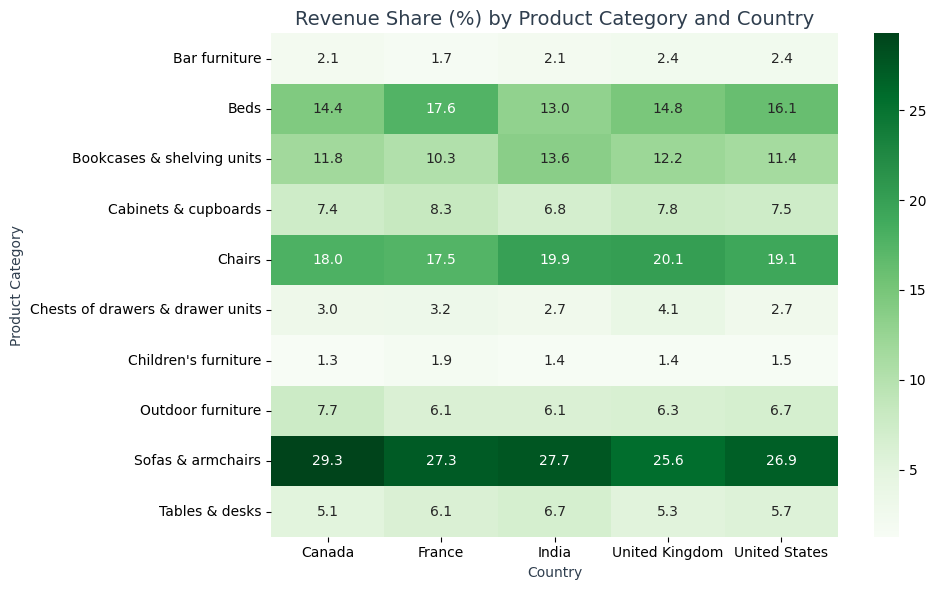

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_revenue_pct,
    annot=True,
    fmt=".1f",
    cmap="Greens"
)

plt.title(
    "Revenue Share (%) by Product Category and Country",
    fontsize=14,
    color=DARK_BLUE
)
plt.xlabel("Country", color=DARK_BLUE)
plt.ylabel("Product Category", color=DARK_BLUE)

plt.tight_layout()
plt.show()


###Finding
**EN:**
Furniture categories such as Sofas & armchairs and Beds consistently generate the highest revenue across most top countries. Some categories perform strongly only in specific markets, indicating local demand differences. Global revenue growth should focus on scaling top-performing categories across countries, while country-specific strategies can be used to promote locally strong categories.

**UA:**
Категорії Sofas & armchairs та Beds стабільно генерують найбільший дохід у більшості топових країн. Водночас деякі категорії добре продаються лише в окремих країнах, що вказує на локальні відмінності попиту. Зростання глобального доходу повинно бути зосереджено на розширенні категорій з найвищими показниками в різних країнах, тоді як стратегії, специфічні для кожної країни, можуть бути використані для просування категорій, що мають сильні позиції на місцевому рівні.

##Revenue by Traffic Channel and Country

In [ ]:
pivot_channel_country = pd.pivot_table(
    df[df["country"].isin(top_countries)],
    values="price",
    index="traffic_source",
    columns="country",
    aggfunc="sum",
    fill_value=0
)

pivot_channel_country

country,Canada,France,India,United Kingdom,United States
traffic_source,,,,,
Direct,609806.3,169299.5,700256.0,203728.9,3346860.3
Organic Search,847821.0,247296.6,889529.2,320413.9,4774846.2
Other,362517.6,94765.3,415159.3,169969.2,1839393.6
Paid Search,78577.6,37058.0,146181.5,49226.6,579847.9
Referral,404162.7,121023.4,464850.5,147317.8,2464690.8


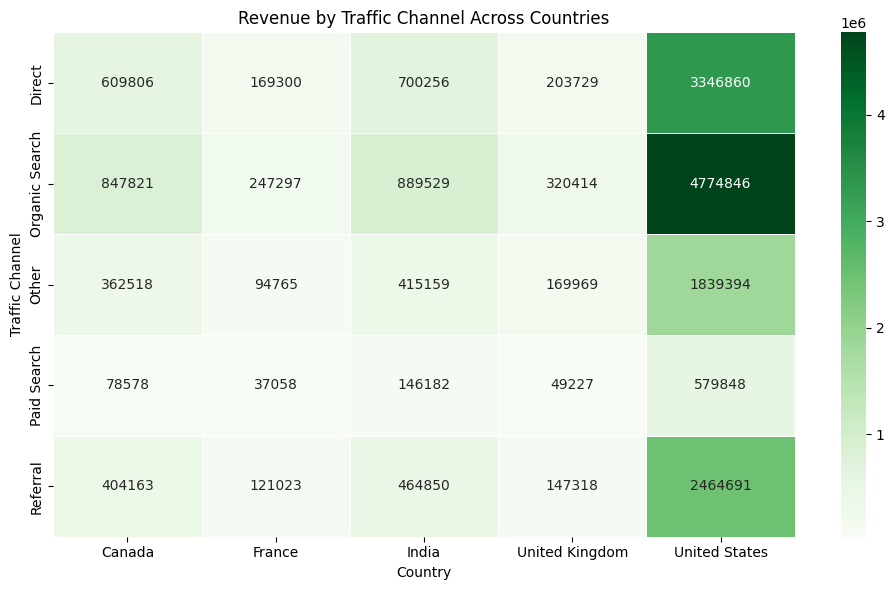

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_channel_country,
    cmap="Greens",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)
plt.title("Revenue by Traffic Channel Across Countries")
plt.xlabel("Country")
plt.ylabel("Traffic Channel")
plt.tight_layout()
plt.show()

###Finding
**EN:**
Traffic channel effectiveness varies significantly by country. A single global channel strategy is suboptimal — channel mix should be localized by market.

**UA:**
Ефективність каналів трафіку суттєво відрізняється між країнами. Єдина маркетингова стратегія для всіх країн неефективна — канали потрібно підбирати окремо для кожного ринку.

##Orders & Revenue by Country and Device

In [ ]:
pivot_country_device = pd.pivot_table(
    df,
    values="price",
    index="country",
    columns="device",
    aggfunc=["sum", "count"],
    fill_value=0
)

pivot_country_device.columns = [
    f"{metric}_{device}"
    for metric, device in pivot_country_device.columns
]

pivot_country_device.sort_values(
    by="sum_desktop", ascending=False
).head(10)


,sum_desktop,sum_mobile,sum_tablet,count_desktop,count_mobile,count_tablet
country,,,,,,
United States,7737993.1,4977995.3,289650.4,8071,5353,312
India,1530839.7,1015800.4,69336.4,1696,1087,63
Canada,1350563.7,905071.5,47250.0,1432,941,40
United Kingdom,520754.4,353680.0,16222.0,578,380,19
France,393482.5,262035.3,13925.0,379,249,11
Spain,379735.4,215409.3,5237.0,374,239,11
Germany,352452.3,205688.6,5630.0,358,230,12
China,317792.1,203353.5,26462.5,320,214,16
Taiwan,301019.3,196350.0,13107.0,306,206,14


###Finding
**EN:**
Desktop generates the largest share of revenue across most countries.
Mobile plays a strong supporting role, especially in high-volume markets.
Tablet contribution is consistently minimal. Marketing and UX optimization should prioritize desktop and mobile experiences.
Tablet optimization is not a short-term priority due to low revenue impact.

**UA:**
У більшості країн основний дохід приносить desktop.
Mobile має значний внесок, але рідко домінує.
Tablet майже не впливає на загальний дохід. Бізнесу варто фокусуватись на desktop та mobile (UX, checkout, маркетинг).
Tablet не потребує окремих інвестицій на цьому етапі.



#Statistical Analysis of Relationships

##Sessions vs Revenue (daily)
**Question:**

**EN:** Does higher traffic volume lead to higher revenue?

**UA:** Чи призводить більший обсяг трафіку до збільшення доходів?

In [ ]:
daily_metrics = (
    df
    .groupby("date")
    .agg(
        sessions=("ga_session_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
)

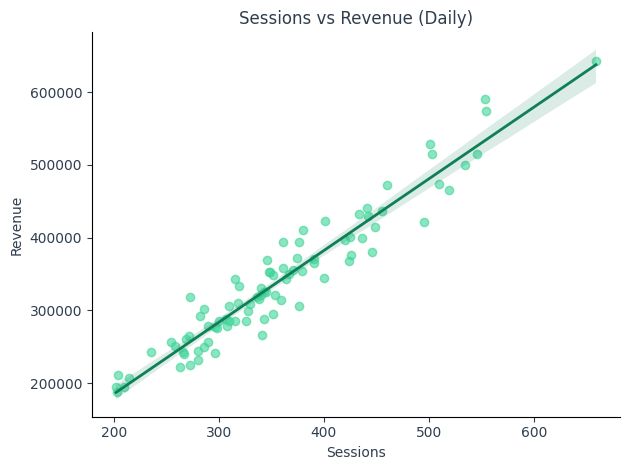

In [ ]:
sns.regplot(
    data=daily_metrics,
    x="sessions",
    y="revenue",
    scatter_kws={
        "color": TEAL_CENTER,
        "alpha": 0.6
    },
    line_kws={
        "color": TEAL_DARK,
        "linewidth": 2
    }
)

plt.title("Sessions vs Revenue (Daily)", color=DARK_BLUE)
plt.xlabel("Sessions", color=DARK_BLUE)
plt.ylabel("Revenue", color=DARK_BLUE)

plt.tick_params(axis="both", colors=DARK_BLUE)
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    daily_metrics["sessions"],
    daily_metrics["revenue"]
)

corr, p_value

(np.float64(0.9593141537448919), np.float64(5.2189185645054966e-49))

###Interpretation
**EN:**
There is a strong positive correlation between the number of sessions and daily revenue. Days with higher traffic tend to generate higher revenue, indicating that traffic volume is a key driver of sales performance.
Increasing traffic volume is likely to result in higher revenue. Marketing efforts aimed at traffic acquisition can be effective, especially when conversion rates remain stable.

**UA:**
Спостерігається сильна позитивна кореляція між кількістю сесій та щоденним доходом. Дні з більшим трафіком зазвичай приносять вищий дохід, що свідчить про важливу роль трафіку в генерації продажів.
Збільшення трафіку з високою ймовірністю призводить до зростання доходу. Інвестиції в залучення користувачів можуть бути ефективними, за умови стабільної конверсії.


##Correlation of Revenue Across Continents

###Question:
**EN:** Do revenues across top-3 continents move together over time, or do they behave independently?

**UA:** Чи змінюються продажі на різних континентах одночасно, чи кожен ринок живе своїм життям?

In [ ]:
continent_daily = (
    df
    .groupby(["date", "continent"])
    .agg(revenue=("price", "sum"))
    .reset_index()
)

In [ ]:
top_continents = (
    continent_daily
    .groupby("continent")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

continent_daily_top = continent_daily[
    continent_daily["continent"].isin(top_continents)
]

In [ ]:
continent_pivot = continent_daily_top.pivot(
    index="date",
    columns="continent",
    values="revenue"
)
continent_pivot

continent,Americas,Asia,Europe
date,,,
2020-11-01,129197.5,63197.0,45419.0
2020-11-02,180782.0,73040.0,70544.8
2020-11-03,276784.8,114703.4,65037.0
2020-11-04,191575.5,60709.0,62395.0
2020-11-05,164698.8,111099.4,73802.0
...,...,...,...
2021-01-23,146201.9,63044.0,62883.6
2021-01-24,107642.9,74801.2,44539.8
2021-01-25,175774.1,63941.2,54161.0


In [ ]:
correlation_results = []

continents = continent_pivot.columns.tolist()

for i in range(len(continents)):
    for j in range(i + 1, len(continents)):
        c1, c2 = continents[i], continents[j]

        temp = continent_pivot[[c1, c2]].dropna()

        corr, p_value = pearsonr(temp[c1], temp[c2])

        correlation_results.append({
            "continent_1": c1,
            "continent_2": c2,
            "correlation": corr,
            "p_value": p_value
        })

correlation_df = pd.DataFrame(correlation_results)
correlation_df


,continent_1,continent_2,correlation,p_value
0,Americas,Asia,0.681888,2.596774e-13
1,Americas,Europe,0.643946,1.306851e-11
2,Asia,Europe,0.667559,1.219651e-12


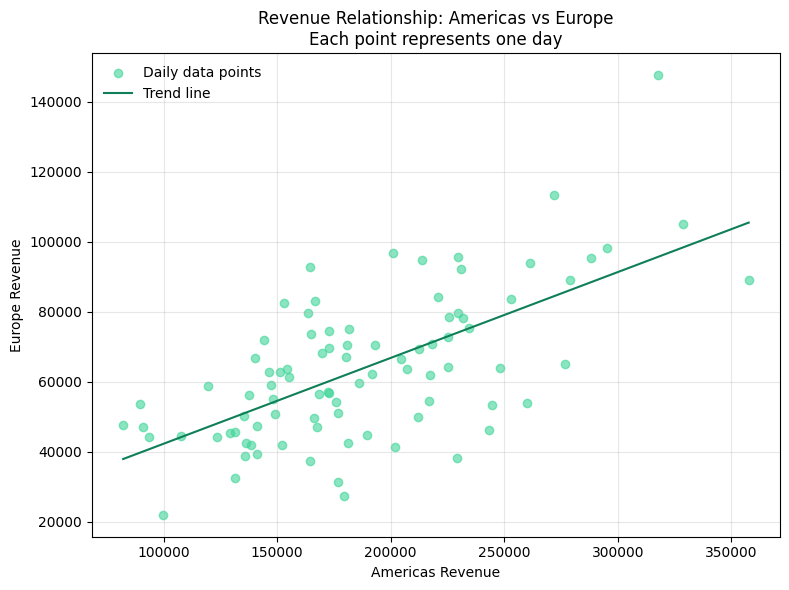

In [ ]:
x = continent_pivot["Americas"]
y = continent_pivot["Europe"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.6,
    color=TEAL_CENTER,
    label="Daily data points")

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(
    x_line,
    trend(x_line),
    color=TEAL_DARK,
    label="Trend line")

plt.xlabel("Americas Revenue")
plt.ylabel("Europe Revenue")
plt.title("Revenue Relationship: Americas vs Europe\nEach point represents one day")

plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

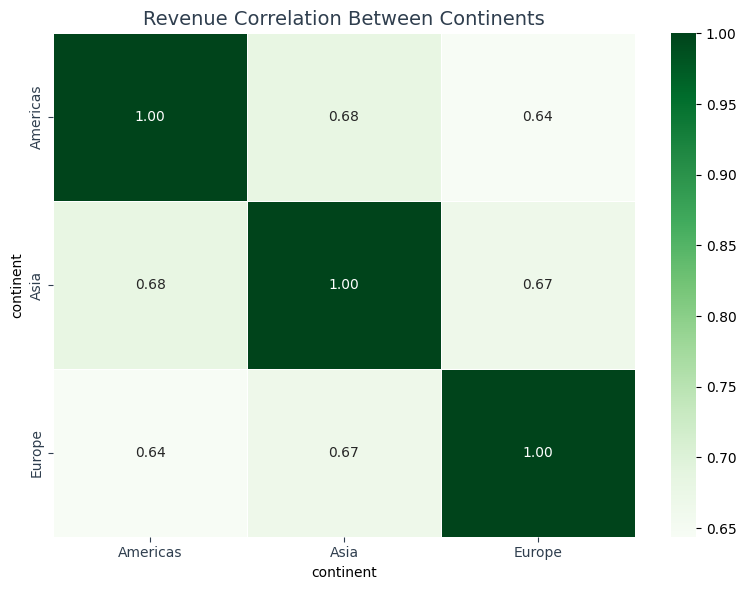

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    continent_pivot.corr(),
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5
)

plt.title(
    "Revenue Correlation Between Continents",
    color=DARK_BLUE,
    fontsize=14
)

plt.tick_params(colors=DARK_BLUE)
plt.tight_layout()
plt.show()


###Interpretation
**EN:**
Sales on different continents change partially at the same time, but each market has its own dynamics. There is a correlation between regions, but it is not high enough to speak of complete synchronism.

Marketing campaigns for continents can be planned together.

**UA:**
Продажі на різних континентах частково змінюються одночасно, але кожен ринок має свою динаміку. Кореляція між регіонами є, але вона не надто висока, щоб говорити про повну синхронність.

Маркетингові кампанії для континентів можна планувати разом.

##Revenue Correlation by Traffic Channel

###Question:
**EN:**
Do revenue dynamics across different traffic channels move together over time, and are these relationships statistically significant?

**UA:**
Чи змінюються продажі за різними каналами трафіку синхронно з часом, і чи є ці взаємозвʼязки статистично значущими?

In [ ]:
channel_time_metrics = (
    df[df["traffic_source"] != "Data Removed"]
    .groupby(["date", "traffic_source"])
    .agg(revenue=("price", "sum"))
    .reset_index()
)

channel_pivot = channel_time_metrics.pivot(
    index="date",
    columns="traffic_source",
    values="revenue"
)


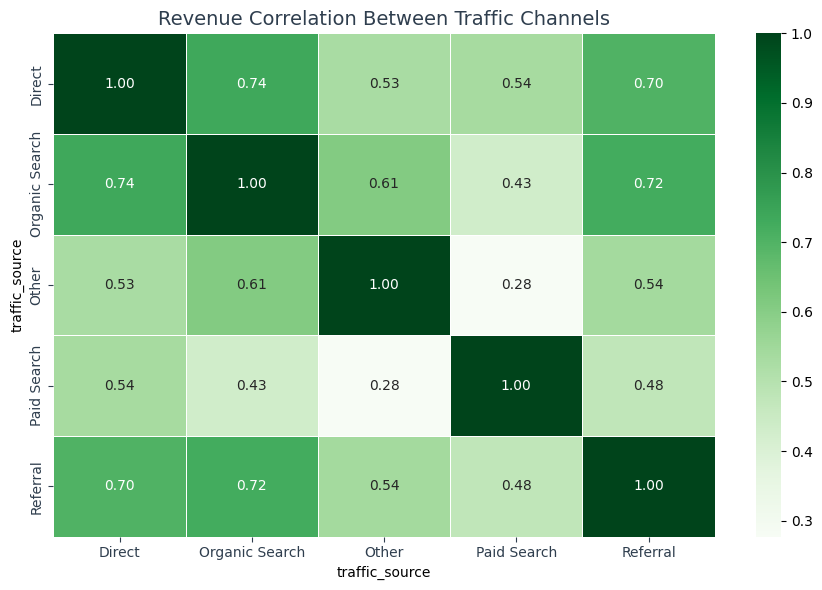

In [ ]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    channel_pivot.corr(),
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5
)

plt.title(
    "Revenue Correlation Between Traffic Channels",
    color=DARK_BLUE,
    fontsize=14
)

plt.tick_params(colors=DARK_BLUE)
plt.tight_layout()
plt.show()


In [ ]:
corr_results = []

channels = channel_pivot.columns

for i in range(len(channels)):
    for j in range(i + 1, len(channels)):
        ch1 = channels[i]
        ch2 = channels[j]

        data = channel_pivot[[ch1, ch2]].dropna()

        corr, p_value = pearsonr(data[ch1], data[ch2])

        corr_results.append({
            "channel_1": ch1,
            "channel_2": ch2,
            "correlation": corr,
            "p_value": p_value
        })

corr_df = pd.DataFrame(corr_results)
corr_df


,channel_1,channel_2,correlation,p_value
0,Direct,Organic Search,0.737228,2.615399e-16
1,Direct,Other,0.530613,1.051706e-07
2,Direct,Paid Search,0.536857,6.967830e-08
3,Direct,Referral,0.701943,2.556761e-14
4,Organic Search,Other,0.609009,3.061755e-10
5,Organic Search,Paid Search,0.430489,2.833749e-05
6,Organic Search,Referral,0.724385,1.504517e-15
7,Other,Paid Search,0.277200,8.932186e-03
8,Other,Referral,0.541630,5.057977e-08
9,Paid Search,Referral,0.475289,2.878810e-06


###Interpretation
**EN:**
Most traffic channels show moderate to strong positive correlations, indicating that revenue changes are often driven by shared external factors such as seasonality or promotions rather than independent channel behavior.
Revenue growth across channels is largely synchronized, suggesting that cross-channel campaigns should be coordinated. Optimizing one channel in isolation is unlikely to produce independent revenue growth.

**UA:**
Більшість каналів трафіку мають помірну або сильну позитивну кореляцію,
що означає: зміни продажів зумовлені спільними факторами (сезонність, акції),
а не незалежною поведінкою окремих каналів. Продажі за каналами змінюються синхронно, тому маркетингові кампанії потрібно планувати комплексно. Оптимізація одного каналу без урахування інших
навряд чи дасть окремий ефект.


##Revenue Correlation by Product Category

###Question:

**EN:**
Do revenues of top product categories move together over time, and are these relationships statistically significant?

**UA:**
Чи змінюються продажі топових категорій товарів одночасно з часом, і чи є ці взаємозв’язки статистично значущими?

In [ ]:
top_categories = (
    df
    .groupby("category")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)


category_daily = (
    df[df["category"].isin(top_categories)]
    .groupby(["date", "category"])
    .agg(revenue=("price", "sum"))
    .reset_index()
)

category_pivot = category_daily.pivot(
    index="date",
    columns="category",
    values="revenue"
)

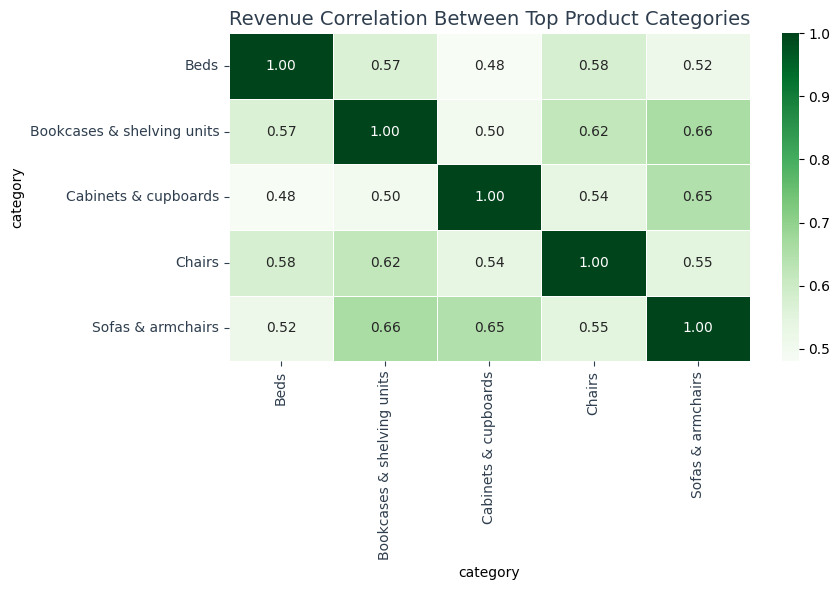

In [ ]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    category_pivot.corr(),
    annot=True,
    fmt=".2f",
    cmap="Greens",
    linewidths=0.5
)

plt.title(
    "Revenue Correlation Between Top Product Categories",
    color=DARK_BLUE,
    fontsize=14
)

plt.tick_params(colors=DARK_BLUE)
plt.tight_layout()
plt.show()



In [ ]:
category_corr_results = []

categories = category_pivot.columns

for i in range(len(categories)):
    for j in range(i + 1, len(categories)):
        c1 = categories[i]
        c2 = categories[j]

        data = category_pivot[[c1, c2]].dropna()

        corr, p_value = pearsonr(data[c1], data[c2])

        category_corr_results.append({
            "category_1": c1,
            "category_2": c2,
            "correlation": corr,
            "p_value": p_value
        })

category_corr_df = pd.DataFrame(category_corr_results)
category_corr_df


,category_1,category_2,correlation,p_value
0,Beds,Bookcases & shelving units,0.567607,8.082161e-09
1,Beds,Cabinets & cupboards,0.480280,2.185935e-06
2,Beds,Chairs,0.578936,3.452663e-09
3,Beds,Sofas & armchairs,0.515488,2.756392e-07
4,Bookcases & shelving units,Cabinets & cupboards,0.498181,7.851551e-07
5,Bookcases & shelving units,Chairs,0.618492,1.351624e-10
6,Bookcases & shelving units,Sofas & armchairs,0.660649,2.495621e-12
7,Cabinets & cupboards,Chairs,0.538198,6.371342e-08
8,Cabinets & cupboards,Sofas & armchairs,0.645547,1.119942e-11
9,Chairs,Sofas & armchairs,0.548781,3.100630e-08


###Interpretation
**EN:**
Most top product categories show moderate to strong positive correlations in revenue over time. This suggests that category performance is influenced by common factors such as seasonality, promotions, or overall demand trends rather than independent category-specific effects. Revenue across product categories tends to move together, suggesting that global demand drivers affect the entire product portfolio. Category-specific optimization should focus on pricing and assortment rather than expecting independent demand growth.


**UA:**
Більшість топових категорій мають помірну або сильну позитивну кореляцію доходів у часі. Це означає, що на продажі впливають спільні фактори — сезонність, акції або загальний попит, а не лише особливості окремих категорій.
Продажі різних категорій зазвичай змінюються одночасно, що вказує на вплив загальних факторів попиту на весь асортимент. Оптимізацію варто зосередити на ціноутворенні та асортименті, а не очікувати незалежного зростання окремих категорій.




##AOV vs Number of Orders

###Question:
**EN:**
Is there a relationship between Average Order Value (AOV) and the number of orders over time?

**UA:**
Чи існує взаємозвʼязок між середнім чеком (AOV) та кількістю замовлень у часі?

In [ ]:
daily_metrics = (
    df
    .groupby("date")
    .agg(
        orders=("ga_session_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
)

daily_metrics["aov"] = daily_metrics["revenue"] / daily_metrics["orders"]


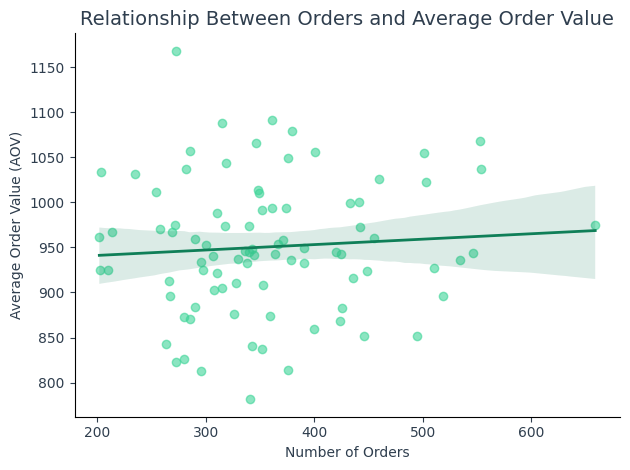

In [ ]:
sns.regplot(
    data=daily_metrics,
    x="orders",
    y="aov",
    scatter_kws={
        "color": TEAL_CENTER,
        "alpha": 0.6
    },
    line_kws={
        "color": TEAL_DARK,
        "linewidth": 2
    }
)

plt.title(
    "Relationship Between Orders and Average Order Value",
    color=DARK_BLUE,
    fontsize=14
)
plt.xlabel("Number of Orders", color=DARK_BLUE)
plt.ylabel("Average Order Value (AOV)", color=DARK_BLUE)

plt.tick_params(axis="both", colors=DARK_BLUE)
sns.despine()
plt.tight_layout()
plt.show()


###Interpretation
**EN:**
There is a negative correlation between the number of orders and AOV. On days with more orders, the average order value tends to be lower. Increasing the number of orders does not automatically increase revenue, as higher volume often comes with lower AOV. Revenue growth should balance traffic and pricing strategies.

**UA:**
Існує негативна кореляція між кількістю замовлень і середньою вартістю замовлення (AOV). У дні з більшою кількістю замовлень середня вартість замовлення, як правило, нижча. Збільшення кількості замовлень не призводить до автоматичного зростання доходу, оскільки більший обсяг часто супроводжується зниженням середньої вартості замовлення (AOV). Зростання доходу повинно бути збалансоване між стратегіями трафіку та ціноутворення.

##Revenue vs AOV

###Question
**EN:**
Is daily revenue more closely related to changes in Average Order Value?

**UA:**
Чи повʼязане зростання доходу зі змінами середнього чеку (AOV)?

In [ ]:
daily_metrics = (
    df
    .groupby("date")
    .agg(
        revenue=("price", "sum"),
        orders=("ga_session_id", "nunique")
    )
    .reset_index()
)

daily_metrics["aov"] = daily_metrics["revenue"] / daily_metrics["orders"]


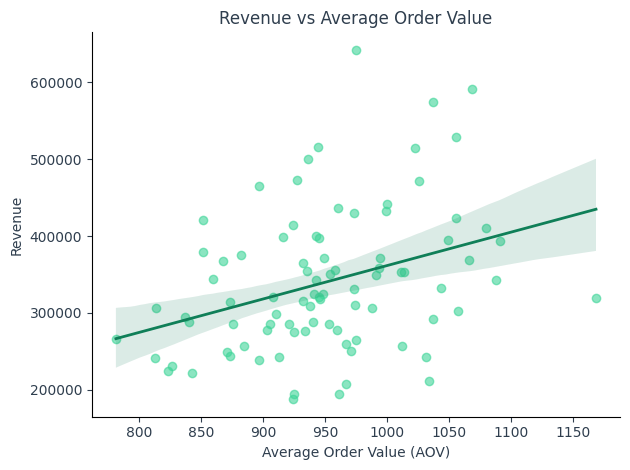

In [ ]:
sns.regplot(
    data=daily_metrics,
    x="aov",
    y="revenue",
    scatter_kws={"color": TEAL_CENTER, "alpha": 0.6},
    line_kws={"color": TEAL_DARK, "linewidth": 2}
)

plt.title("Revenue vs Average Order Value", color=DARK_BLUE)
plt.xlabel("Average Order Value (AOV)", color=DARK_BLUE)
plt.ylabel("Revenue", color=DARK_BLUE)

plt.tick_params(axis="both", colors=DARK_BLUE)
sns.despine()
plt.tight_layout()
plt.show()


###Interpretation
**EN:**
Revenue tends to increase when the average order value increases. Days with higher AOV generally generate higher revenue, even when the number of orders is similar. Revenue growth can be achieved by improving monetization efficiency.
Increasing AOV through pricing optimization, bundles, or upsell strategies can lead to higher revenue without increasing traffic.

**UA:**
Коли середній чек зростає, дохід за день зазвичай теж зростає. Навіть без збільшення кількості замовлень вищий AOV призводить до більшого доходу. Дохід можна збільшувати за рахунок ефективнішої монетизації.
Підвищення середнього чека через оптимізацію цін, бандли або апсел може дати приріст доходу без зростання трафіку.

#Statistical Analysis of Differences Between Groups

##Registered vs Unregistered users — Sales comparison over time

###Question

**EN:**
Do registered users generate higher daily revenue compared to unregistered users?

**UA:**
Чи приносять зареєстровані користувачі більший дохід порівняно з незареєстрованими?

In [ ]:
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
df_users = df.copy()

df_users["user_type"] = np.where(
    df_users["registered_user_id"].notna(),
    "Registered",
    "Unregistered"
)

daily_user_revenue = (
    df_users
    .groupby(["date", "user_type"])
    .agg(revenue=("price", "sum"))
    .reset_index()
)
daily_user_revenue

,date,user_type,revenue
0,2020-11-01,Registered,21547.0
1,2020-11-01,Unregistered,217825.5
2,2020-11-02,Registered,38398.8
3,2020-11-02,Unregistered,292533.0
4,2020-11-03,Registered,27010.5
...,...,...,...
171,2021-01-25,Unregistered,262487.5
172,2021-01-26,Registered,24823.6
173,2021-01-26,Unregistered,333898.7
174,2021-01-27,Registered,14484.6


In [ ]:
reg_rev = daily_user_revenue.query("user_type == 'Registered'")["revenue"]
unreg_rev = daily_user_revenue.query("user_type == 'Unregistered'")["revenue"]

In [ ]:
for channel in df["traffic_source"].unique():
    sample = df[df["traffic_source"] == channel]["ga_session_id"]

    stat, p_value = shapiro(sample.sample(500, random_state=42))

    print(f"{channel}: p-value = {p_value}")

Organic Search: p-value = 3.084448151829632e-10
Direct: p-value = 3.956554204331695e-12
Referral: p-value = 7.691693508756007e-12
Other: p-value = 2.27270398763479e-11
Paid Search: p-value = 2.3372838319422006e-11


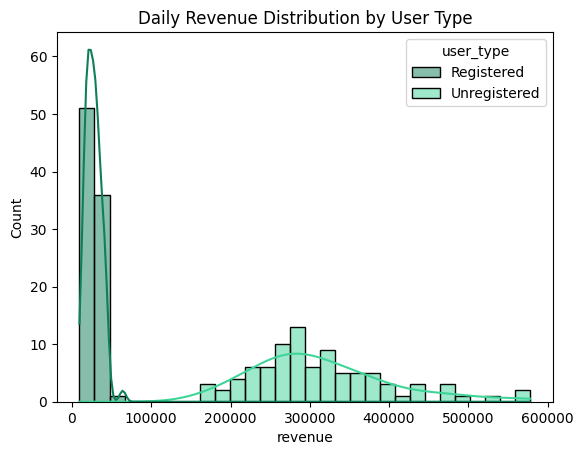

In [ ]:
sns.histplot(
    data=daily_user_revenue,
    x="revenue",
    hue="user_type",
    bins=30,
    kde=True,
    palette={"Unregistered": TEAL_CENTER, "Registered": TEAL_DARK}
)
plt.title("Daily Revenue Distribution by User Type")
plt.show()


In [ ]:
u_stat, p_value = mannwhitneyu(
    reg_rev,
    unreg_rev,
    alternative="two-sided"
)

p_value

np.float64(2.2159276950123465e-30)

###Statistical interpretation
**EN:**
Mann–Whitney U test was used to compare revenue distributions between registered and unregistered users, as the data is non-normally distributed.
The test result indicates that the difference is statistically significant, suggesting that user registration status does influence revenue per session.
In many e-commerce platforms, most purchases are made by guest **unregistered users.** Since revenue distributions differ between registered and unregistered users, monetization strategies should be tailored separately for each group. Registration alone should not be treated as a direct revenue driver.

**UA:**
Для порівняння розподілів доходу між зареєстрованими та незареєстрованими користувачами було використано тест Mann–Whitney U, оскільки дані не відповідають нормальному розподілу.
Результати тесту показали, що різниця є статистично значущою, що свідчить про те, що статус реєстрації впливає на дохід на сесію.
У більшості онлайн-магазинів переважна частина покупок робиться **без реєстрації.** Оскільки розподіли доходу відрізняються між зареєстрованими та незареєстрованими користувачами, стратегії монетизації слід будувати окремо для кожної групи. Реєстрацію не варто розглядати як прямий драйвер доходу.

##Analysis of the number of sessions across different traffic channels

###**Question:**

**EN:** Is there a statistically significant difference in the number of sessions between traffic channels?

**UA:**
Чи відрізняється кількість сесій між каналами трафіку статистично значущо?

In [ ]:
daily_channel_sessions = (
    df
    .groupby(["date", "traffic_source"])
    .agg(
        sessions=("ga_session_id", "nunique")
    )
    .reset_index()
)

In [ ]:
for channel, group in daily_channel_sessions.groupby("traffic_source"):
    sample = group["sessions"].sample(
        n=min(500, len(group)),
        random_state=42
    )
    stat, p_value = shapiro(sample)
    print(f"{channel}: p-value = {p_value:.4f}")

Direct: p-value = 0.0928
Organic Search: p-value = 0.0034
Other: p-value = 0.0406
Paid Search: p-value = 0.0211
Referral: p-value = 0.0275


###Interpretation
**EN:**
Normality of session distributions was tested for each traffic channel. The results indicate that session data do not follow a normal distribution, which justifies the use of non-parametric statistical tests.

**UA:**
Було перевірено нормальність розподілу кількості сесій для кожного каналу трафіку. Результати показали, що дані не відповідають нормальному розподілу, тому для подальшого аналізу доцільно використовувати непараметричні статистичні тести.

In [ ]:
groups = [
    group["sessions"].values
    for _, group in daily_channel_sessions.groupby("traffic_source")
]

h_stat, p_value = kruskal(*groups)

h_stat, p_value

(np.float64(347.5757080147004), np.float64(5.853359968365377e-74))

###Interpretation
**EN:**
There are statistically significant differences in session volumes across traffic channels. Traffic channels contribute unequally to session volume, so channel-level optimization is required rather than uniform budget allocation.

**UA:**
Між каналами трафіку існують статистично значущі відмінності в кількості сесій. Канали трафіку мають різний внесок у залучення сесій, тому бюджет і зусилля варто оптимізувати окремо для кожного каналу.

##Organic traffic share: Europe vs America

###**Question**

**EN:**
Is the proportion of organic traffic sessions statistically different between Europe and America?

**UA:**
Чи відрізняється статистично частка сесій з органічного трафіку між Європою та Америкою?

**EN:** This is categorical data (organic/not organic), so we choose the `z-test`.

**UA:** Це категоріальні дані (organic / not organic), тому вибираємо `z-test`.

In [ ]:
df_regions = df[
    df["continent"].isin(["Europe", "Americas"])
].copy()

df_regions["is_organic"] = (
    df_regions["traffic_source"] == "Organic Search"
)

organic_stats = (
    df_regions
    .groupby("continent")
    .agg(
        organic_sessions=("is_organic", "sum"),
        total_sessions=("ga_session_id", "nunique")
    )
)

organic_stats


,organic_sessions,total_sessions
continent,,
Americas,6290,17361
Europe,2147,5912


In [ ]:
counts = organic_stats["organic_sessions"].values
nobs = organic_stats["total_sessions"].values

z_stat, p_value = proportions_ztest(counts, nobs)

z_stat, p_value

(np.float64(-0.11788507331636115), np.float64(0.9061587205411596))

###Interpretation
**EN:**
A two-proportion z-test was used to compare the share of organic traffic between Europe and America.
The test results indicate that the difference in organic traffic share is  not statistically significant.

**UA:**
Для порівняння частки органічного трафіку між Європою та Америкою було використано z-тест для двох пропорцій.
Результати тесту показали, що різниця  не є статистично значущою.

##Well-Known Statistical Test

**UA:**
- t-тест Стьюдента – для порівняння середніх значень між двома групами.
- ANOVA (дисперсійний аналіз) – для порівняння середніх між трьома і більше групами.
- Тест Вілкоксона – для парних вибірок, коли дані не відповідають нормальному розподілу.
- Кореляційний аналіз (Пірсона, Спірмена) – для вимірювання сили та напрямку зв’язку між змінними.
- Тест Краскела–Уолліса – непараметричний аналог ANOVA.

**EN:**
- Student’s t-test – used to compare the means between two groups.
- ANOVA (Analysis of Variance) – used to compare means across three or more groups.
- Wilcoxon signed-rank test – for paired samples when data are not normally distributed.
- Correlation analysis (Pearson, Spearman) – measures the strength and direction of relationships between variables.
- Kruskal–Wallis test – a nonparametric alternative to ANOVA.


#  Final Conclusions & Business Insights



---

##1. Geography: Continents

### **Finding (EN)**

The highest total revenue and number of orders come from **Americas and Europe**.
At the same time, several top countries by order volume have **below-median AOV**, indicating strong demand but weak monetization. Revenue growth should focus on **increasing AOV in existing high-demand markets**, rather than expanding to new regions.

### **Висновок (UA)**

Найбільший дохід і кількість замовлень генерують **Америка та Європа**.
Водночас частина країн з високою кількістю замовлень має **AOV нижчий за медіану**, що свідчить про високий попит, але слабку монетизацію. Зростання доходу варто шукати в **підвищенні середнього чека в наявних сильних ринках**, а не в географічному розширенні.

---

## 2. Product Categories

### **Finding (EN)**

A small number of product categories generate a disproportionate share of total revenue.
Some high-demand categories fall into the **“high demand / low monetization”** segment. Optimizing pricing, bundles, and cross-sell strategies in top categories offers the fastest revenue uplift.

### **Висновок (UA)**

Невелика кількість категорій формує основну частину доходу.
Частина популярних категорій має високий попит, але **низьку монетизацію**. Оптимізація цін, наборів та крос-продажів у топ-категоріях є найшвидшим шляхом до зростання доходу.

---

## 3. Traffic Channels

### **Finding (EN)**

Organic Search and Direct channels generate the majority of sessions and revenue.
Paid and Other channels generate traffic but show **lower revenue per session**.
Statistical testing (Kruskal–Wallis) confirms that session volumes differ significantly across channels. Traffic channels should be managed based on **value, not volume**. Paid channels require optimization, not blind scaling.

### **Висновок (UA)**

Organic Search та Direct приносять більшість сесій і доходу.
Paid та Other канали генерують трафік, але з **нижчою ефективністю монетизації**.
Тест Краскела–Уолліса підтвердив статистично значущі відмінності між каналами. Канали трафіку слід оцінювати за **цінністю, а не обсягом**. Платні канали потребують оптимізації, а не автоматичного масштабування.

---

## 4. Devices

### **Finding (EN)**

Desktop devices generate the largest share of revenue with stable AOV.
Mobile generates a high number of sessions but has **lower revenue efficiency**.
Tablet contribution is minimal. Mobile performance issues are likely related to UX or checkout friction rather than traffic acquisition.

### **Висновок (UA)**

Desktop є основним драйвером доходу зі стабільним AOV.
Mobile має великий трафік, але **нижчу ефективність монетизації**.
Tablet майже не впливає на загальні продажі. Проблема mobile — не в трафіку, а в UX або процесі оформлення замовлення.

---

## 5. Registered vs Unregistered Users

### **Finding (EN)**

Unregistered users generate **higher revenue per session** than registered users.
The difference is statistically significant based on the Mann–Whitney U test. Registration does not increase short-term monetization and may introduce friction.
Its value should be evaluated via retention and lifetime value (LTV).

### **Висновок (UA)**

Незареєстровані користувачі мають **вищий дохід на сесію**, ніж зареєстровані.
Різниця є статистично значущою (тест Манна–Вітні). Реєстрація не демонструє помітного короткострокового впливу на дохід. Її ефективність доцільніше оцінювати через утримання користувачів та показники LTV.

---

## 6. Seasonality & Sales Dynamics

### **Finding (EN)**

Sales exhibit consistent weekly and monthly seasonality with recurring peaks and declines.
Observed fluctuations follow stable patterns rather than random noise. Marketing campaigns and performance evaluation should account for seasonality effects.

### **Висновок (UA)**

Продажі мають стабільну тижневу та місячну сезонність із повторюваними піками та спадами. Маркетингові кампанії та оцінка ефективності мають враховувати сезонність.

---

## 7. Organic Traffic: Europe vs America

### **Finding (EN)**

A two-proportion z-test showed **no statistically significant difference** in the share of organic sessions between Europe and America (p-value = 0.906). SEO effectiveness appears consistent across these regions, allowing for a unified SEO strategy at the regional level.

### **Висновок (UA)**

Z-тест для двох пропорцій показав **відсутність статистично значущої різниці** у частці органічного трафіку між Європою та Америкою (p-value = 0.906). SEO працює подібним чином у Європі та Америці, тому можливе використання єдиної регіональної SEO-стратегії.

---

#Final Business Summary

### **EN**

The main growth opportunities lie in **improving monetization rather than increasing traffic**:

* increasing AOV in high-demand regions and categories
* optimizing mobile user experience
* prioritizing high-value traffic channels

### **UA**

Основні можливості зростання — це **покращення монетизації, а не збільшення трафіку**:

* підвищення AOV у популярних регіонах і категоріях
* оптимізація mobile-досвіду
* фокус на каналах з високою цінністю



#Tableau
##[Analysis Online Store](https://public.tableau.com/app/profile/daryna.nakonechna/viz/AnalysisOnlineStore/Dashboard)